Исходная литосфера: 125.0 км
Новая литосфера:    41.7 км
Коэффициент схемы r = 0.153 (должен быть <= 0.5 для устойчивости FTCS)
q до рифтинга ~ -20.8 mW/m^2
q сразу после рифтинга (0+) ~ -62.4 mW/m^2
q через 100 Myr ~ -31.7 mW/m^2


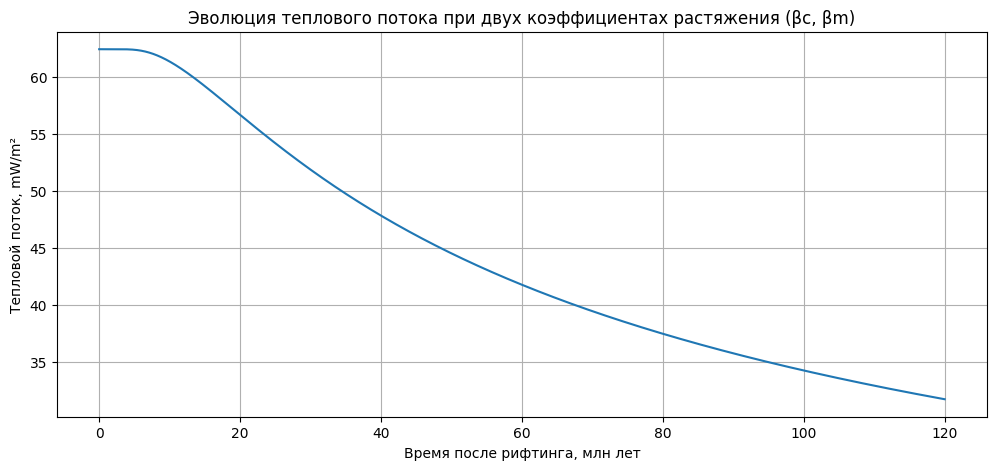

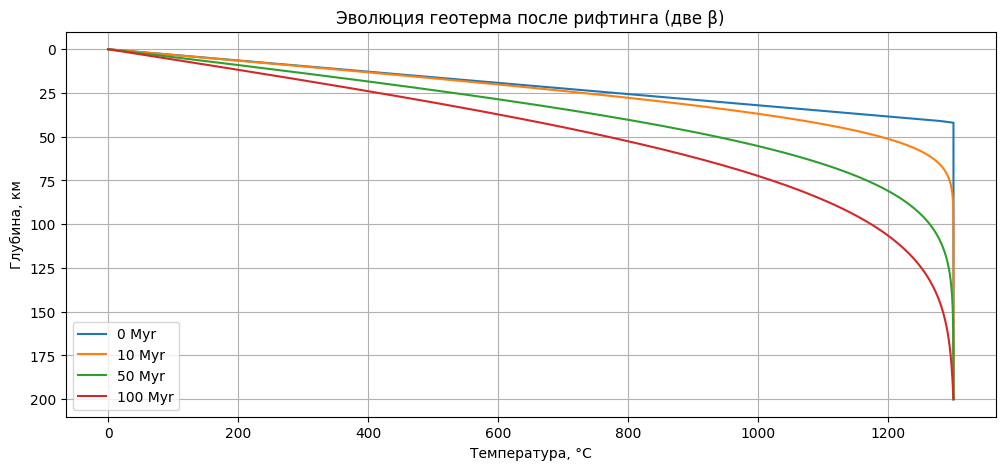

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Параметры модели

Ts = 0.0          # температура поверхности, °C
Tm = 1300.0       # температура астеносферы, °C

hc0 = 30e3        # исходная толщина коры, м
hm0 = 95e3        # исходная толщина мантии литосферы, м
zl0 = hc0 + hm0   # исходная толщина литосферы, м

# коэффициенты растяжения
beta_c = 3.0      # кора
beta_m = 3.0      # мантия литосферы

# новые толщины после рифтинга
hc = hc0 / beta_c
hm = hm0 / beta_m
zl_new = hc + hm  # новая толщина литосферы

print(f"Исходная литосфера: {zl0/1000:.1f} км")
print(f"Новая литосфера:    {zl_new/1000:.1f} км")

# термические свойства
k = 2.0           # теплопроводность, W/m/K
rho = 3300.0      # плотность, kg/m3
Cp = 1250.0       # теплоёмкость, J/kg/K
kappa = k / (rho * Cp)  # температуропроводность, м2/с

# расчётный домен по глубине
Zmax = 200e3      # глубина модели, м
nz = 201          # число узлов по z
z = np.linspace(0, Zmax, nz)
dz = z[1] - z[0]

# ------------------------------
# Исходный геотерм до рифтинга

T0 = np.zeros_like(z)
for i, zi in enumerate(z):
    if zi <= zl0:
        T0[i] = Ts + (Tm - Ts) * (zi / zl0)
    else:
        T0[i] = Tm

# ------------------------------
#  Начальный профиль после растяжения (t = 0+)
#    с двумя бета: beta_c и beta_m

T = np.zeros_like(z)

for i, z_new in enumerate(z):
    if z_new <= hc:
        # кора: материал пришёл с глубины z_old = z_new * beta_c
        z_old = z_new * beta_c
    elif z_new <= zl_new:
        # мантия литосферы: материал пришёл из старой мантии литосферы
        z_old = hc0 + (z_new - hc) * beta_m
    else:
        # астеносфера, считаем изотермической
        z_old = zl0 + (z_new - zl_new)

    # ограничиваем диапазон
    if z_old >= Zmax:
        T[i] = T0[-1]
    else:
        # линейная интерполяция T0(z_old)
        j = int(z_old // dz)
        if j >= nz - 1:
            T[i] = T0[-1]
        else:
            w = (z_old - z[j]) / dz
            T[i] = (1 - w) * T0[j] + w * T0[j + 1]

T_init = T.copy()

t_max_Myr = 120.0      # моделируем до 100 млн лет
dt_Myr = 0.01          # шаг 0.01 млн лет (~10 тыс. лет)
dt_s = dt_Myr * 1e6 * 365.25 * 24 * 3600
nsteps = int(t_max_Myr / dt_Myr)

r = kappa * dt_s / dz**2
print(f"Коэффициент схемы r = {r:.3f} (должен быть <= 0.5 для устойчивости FTCS)")

# функция для расчёта теплового потока у поверхности
def surface_heatflow(T_profile):
    dTdz = (T_profile[1] - Ts) / dz
    q = -k * dTdz      # W/m2
    return q


times_Myr = np.linspace(0, t_max_Myr, nsteps+1)
heatflow = np.zeros(nsteps+1)

heatflow[0] = surface_heatflow(T_init)

snapshot_times = [0.0, 10.0, 50.0, 100.0]  # Myr
snapshots = {0.0: T_init.copy()}

for n in range(1, nsteps+1):
    T_new = T.copy()
    # внутренние узлы (FTCS)
    T_new[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])

    # граничные условия
    T_new[0] = Ts
    T_new[-1] = Tm

    T = T_new
    heatflow[n] = surface_heatflow(T)

    t_Myr = n * dt_Myr
    for ts in snapshot_times:
        if (ts not in snapshots) and abs(t_Myr - ts) < dt_Myr/2:
            snapshots[ts] = T.copy()

q_before = surface_heatflow(T0)
print(f"q до рифтинга ~ {q_before*1e3:.1f} mW/m^2")
print(f"q сразу после рифтинга (0+) ~ {heatflow[0]*1e3:.1f} mW/m^2")
print(f"q через 100 Myr ~ {heatflow[-1]*1e3:.1f} mW/m^2")


# Эволюция теплового потока
plt.figure()
plt.plot(times_Myr, np.abs(heatflow) * 1e3)
plt.xlabel("Время после рифтинга, млн лет")
plt.ylabel("Тепловой поток, mW/m²")
plt.title("Эволюция теплового потока при двух коэффициентах растяжения (βc, βm)")
plt.grid(True)
plt.show()

# Температурные профили
plt.figure()
for ts in snapshot_times:
    T_snap = snapshots.get(ts, None)
    if T_snap is not None:
        plt.plot(T_snap, z/1000.0, label=f"{ts:.0f} Myr")
plt.gca().invert_yaxis()
plt.xlabel("Температура, °C")
plt.ylabel("Глубина, км")
plt.title("Эволюция геотерма после рифтинга (две β)")
plt.legend()
plt.grid(True)
plt.show()


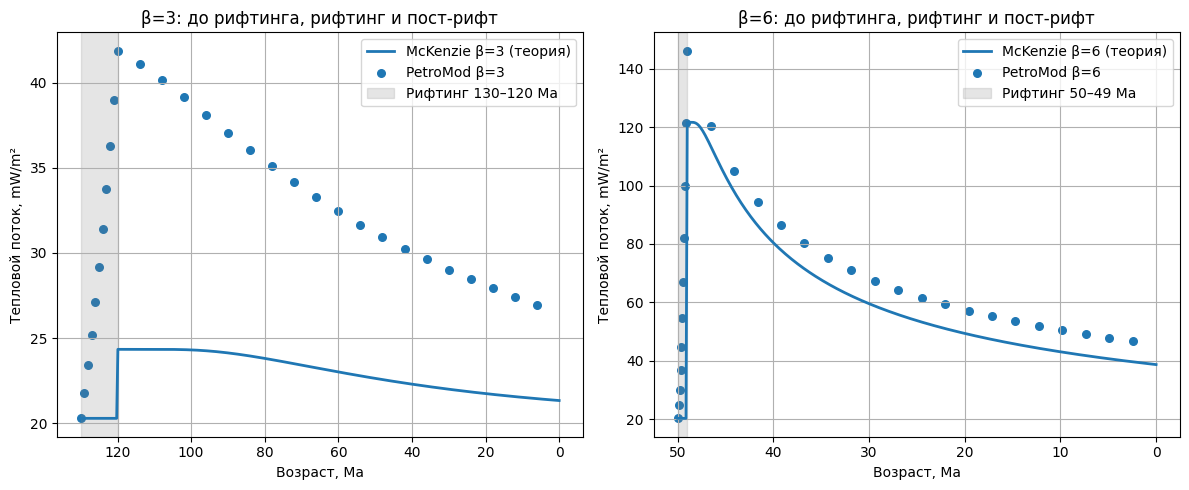

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Теоретическая модель МакКензи 
def mckenzie_q_over_q0(t_after, beta, tau_myr=60.0, n_terms=200):
    """
    q(t)/q0 для МакКензи, t_after >= 0 — время после КОНЦА рифтинга.
    Для t_after < 0 эта функция не используется (там просто q = q0).
    """
    t_after = np.atleast_1d(t_after).astype(float)
    n = np.arange(1, n_terms + 1)[:, None]
    sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
    exp_term = np.exp(- (n ** 2) * (t_after[None, :] / tau_myr))
    q_over_q0 = 1.0 + 2.0 * beta * np.sum(sin_term * exp_term, axis=0)
    return q_over_q0

# -----------------------------
# Данные PetroMod
ages1 = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102, 96, 90, 84, 78, 72, 66, 60, 54,
     48, 42, 36, 30, 24, 18, 12,  6
], dtype=float)

q1 = np.array([
    20.28,21.79,23.43,25.20,27.11,29.17,31.39,33.76,36.30,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,31.67,
    30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)

t_end1 = 120.0   # конец рифтинга
q0_1 = q1[0]     # берем q0 как значение до рифтинга (Age=130 Ma)

# Кейс 2: beta=6, рифтинг 50–49 Ma, конец рифта в 49 Ma
ages2 = np.array([
    50.00,49.90,49.80,49.70,49.60,49.50,49.40,49.30,49.20,49.10,49.00,
    46.55,44.10,41.65,39.20,36.75,34.30,31.85,29.40,26.95,24.50,22.05,
    19.60,17.15,14.70,12.25, 9.80, 7.35, 4.90, 2.45
], dtype=float)

q2 = np.array([
    20.28, 24.70, 30.10, 36.71, 44.81, 54.78, 67.03, 81.98,100.01,121.38,146.18,
   120.40,104.86, 94.24, 86.34, 80.16, 75.14, 70.95, 67.40, 64.33, 61.64, 59.27,
    57.14, 55.24, 53.51, 51.93, 50.48, 49.15, 47.92, 46.78
], dtype=float)

t_end2 = 49.0
q0_2 = q2[0]

# -----------------------------
# 3. Теоретические кривые по ВОЗРАСТУ 
tau = 60.0  # Myr

# --- Кейс 1 ---
beta1 = 1.2
age_grid1 = np.linspace(130, 0, 400)  # от 140 Ma до 0 Ma
t_after1 = t_end1 - age_grid1  # >0 после рифта; <0 до рифта

q_theor1 = np.empty_like(age_grid1)
# до рифтинга: q = q0
mask_pre1 = t_after1 < 0
q_theor1[mask_pre1] = q0_1

# после рифтинга: МакКензи
mask_post1 = t_after1 >= 0
q_theor1[mask_post1] = q0_1 * mckenzie_q_over_q0(t_after1[mask_post1], beta1, tau_myr=tau)

# --- Кейс 2 ---
beta2 = 6.0
age_grid2 = np.linspace(50, 0, 400)   # от 50 Ma до 0 Ma

t_after2 = t_end2 - age_grid2

q_theor2 = np.empty_like(age_grid2)
mask_pre2 = t_after2 < 0
q_theor2[mask_pre2] = q0_2
mask_post2 = t_after2 >= 0
q_theor2[mask_post2] = q0_2 * mckenzie_q_over_q0(t_after2[mask_post2], beta2, tau_myr=tau)

# -----------------------------
# Графики (по возрасту)
plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)


ax = axes[0]
ax.plot(age_grid1, q_theor1, label='McKenzie β=3 (теория)', lw=2)
ax.scatter(ages1, q1, label='PetroMod β=3', s=30)
ax.axvspan(130, 120, color='grey', alpha=0.2, label='Рифтинг 130–120 Ma')
ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β=3: до рифтинга, рифтинг и пост-рифт')
ax.invert_xaxis()  # возраст уменьшается слева направо
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(age_grid2, q_theor2, label='McKenzie β=6 (теория)', lw=2)
ax.scatter(ages2, q2, label='PetroMod β=6', s=30)
ax.axvspan(50, 49, color='grey', alpha=0.2, label='Рифтинг 50–49 Ma')
ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β=6: до рифтинга, рифтинг и пост-рифт')
ax.invert_xaxis()
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


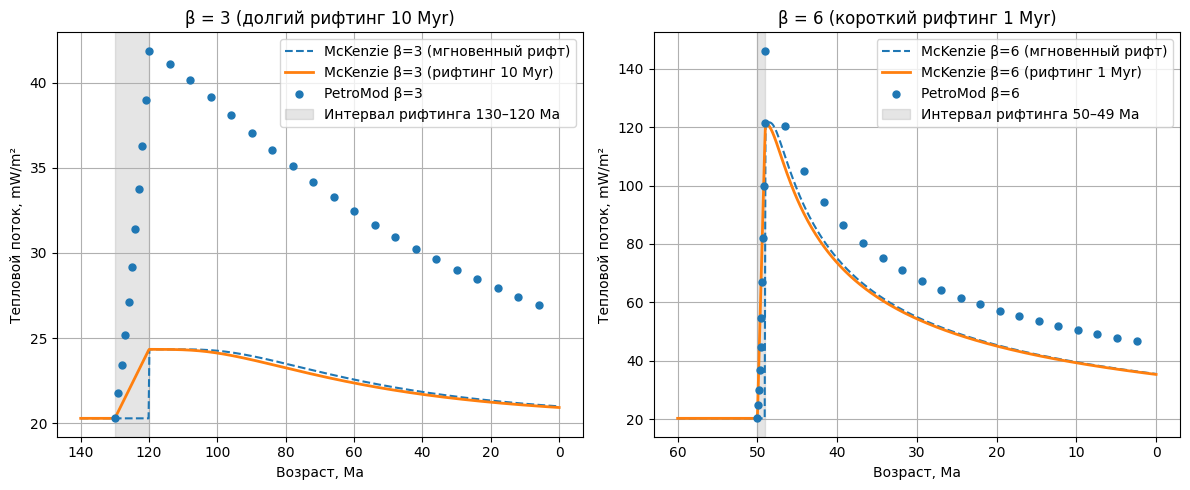

КЕЙС β=3:
  q0 PetroMod             = 20.28
  PetroMod в конце рифта = 41.89 → q/q0 ≈ 2.0655818540433923
  Теория мгновенный рифт = 22.59771428571421 → q/q0 ≈ 1.1142857142857105
  Теория рифт 10 Myr     = 24.312707469012018 → q/q0 ≈ 1.1988514531071015

КЕЙС β=6:
  q0 PetroMod             = 20.28
  PetroMod в конце рифта = 146.18 → q/q0 ≈ 7.208086785009862
  Теория мгновенный рифт = 103.09000011647666 → q/q0 ≈ 5.083333339076758
  Теория рифт 1 Myr      = 119.96072107796465 → q/q0 ≈ 5.9152229328384935


In [81]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Классический МакКензи: мгновенный рифтинг (A=0)
# ============================================================
def mckenzie_q_over_q0_instant(t_after, beta, tau_myr=60.0, n_terms=200):
    """
    Классическая формула МакКензи для мгновенного растяжения.
    t_after >= 0 — время после КОНЦА рифтинга (Myr).
    q(t)/q0 = 1 + 2*beta * sum_{n=1}^∞ [ sin(n*pi/beta)/(n*pi) * exp(-n^2 * t / tau) ]
    """
    t_after = np.atleast_1d(t_after).astype(float)
    q_over_q0 = np.ones_like(t_after)

    # Если есть t<0, там просто q=q0
    mask = t_after > 0
    if not np.any(mask):
        return q_over_q0 if t_after.size > 1 else float(q_over_q0[0])

    t_pos = t_after[mask]

    n = np.arange(1, n_terms + 1, dtype=float)[:, None]  # (N,1)
    sin_term = np.sin(n * np.pi / beta) / (n * np.pi)    # (N,1)
    exp_term = np.exp(- (n ** 2) * (t_pos[None, :] / tau_myr))  # (N, Nt)

    q_over_q0_pos = 1.0 + 2.0 * beta * np.sum(sin_term * exp_term, axis=0)
    q_over_q0[mask] = q_over_q0_pos

    return q_over_q0 if t_after.size > 1 else float(q_over_q0[0])


# ============================================================
# 2. МакКензи с КОНЕЧНЫМ временем рифтинга (линейная β(t))
# ============================================================
"""
Идея: растяжение идёт с постоянной скоростью в течение T_rift.
Общая амплитуда каждого гармонического члена такая же, как при мгновенном рифте
(2*beta * sin(nπ/β)/(nπ)), но эта амплитуда «вкладывается» постепенно
равномерно по времени рифтинга.

Для каждого n:
  A_n = 2 * beta * sin(nπ/β) / (nπ)

При равномерном рифтинге (0..T_rift):
  вклад в аномалию q(t) получается свёрткой A_n с экспонентой релаксации.

Результат (замкнутая формула):

Если 0 < t < T_rift (ещё идёт рифтинг):
  Δq_n(t)/q0 = A_n * (τ_n / T_rift) * [1 - exp(-t/τ_n)],  τ_n = tau_myr / n^2

Если t >= T_rift (пост-рифт):
  Δq_n(t)/q0 = A_n * (τ_n / T_rift) * [exp(-(t - T_rift)/τ_n) - exp(-t/τ_n)]

Если t <= 0 (до начала рифтинга): Δq_n = 0, q = q0.

В пределе T_rift → 0 эта формула переходит в классический мгновенный рифт.
"""


def mckenzie_q_over_q0_finite_t(t, beta, T_rift, tau_myr=60.0, n_terms=200):
    """
    t         : время с МОМЕНТА НАЧАЛА рифтинга (Myr, может быть массив).
                t=0 — начало рифта, t=T_rift — конец рифта.
    beta      : конечное растяжение (β_final).
    T_rift    : длительность рифтинга (Myr).
    tau_myr   : тепловая константа литосферы (Myr).
    n_terms   : число гармоник в ряду.

    Возвращает массив q(t)/q0.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    # Гармоники
    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta * np.sin(n * np.pi / beta) / (n * np.pi)  # амплитуда как в мгновенном рифте
    tau_n = tau_myr / (n ** 2)                                 # своя τ_n для каждой гармоники

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # идёт рифтинг
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # пост-рифт
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age(age_array, age_start_rift, age_end_rift,
                          beta, tau_myr, q0, n_terms=200):
    """
    Обёртка над mckenzie_q_over_q0_finite_t, но в ОСИ ВОЗРАСТА (Ma).

    age_array     : массив возрастов (Ma, чем больше — тем старше).
    age_start_rift: возраст начала рифтинга (например, 130 Ma).
    age_end_rift  : возраст конца рифтинга (например, 120 Ma).
    beta          : конечное растяжение.
    tau_myr       : tau в Myr.
    q0            : дорифтовый тепловой поток (mW/m^2).
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift  # длительность рифта > 0

    # Время с начала рифтинга (tm): tm = 0 при age = age_start_rift
    # При уменьшении возраста tm растёт.
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)

    # Для tm > 0 применяем конечный рифт
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t(
            t_from_start[mask], beta, T_rift, tau_myr=tau_myr, n_terms=n_terms
        )

    # Для tm <= 0 q/q0 = 1 (до начала рифта)
    return q0 * q_over_q0


# ============================================================
# 3. Данные PetroMod
# ============================================================

# --- Кейс 1: beta=3, рифтинг 130–120 Ma ---
ages1 = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102, 96, 90, 84, 78, 72, 66, 60, 54,
     48, 42, 36, 30, 24, 18, 12,  6
], dtype=float)

q1 = np.array([
    20.28,21.79,23.43,25.20,27.11,29.17,31.39,33.76,36.30,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,31.67,
    30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)

age_start1 = 130.0
age_end1   = 120.0
beta1      = 1.2
q0_1       = q1[0]       # дорифтовый q (Age=130 Ma)

# --- Кейс 2: beta=6, рифтинг 50–49 Ma ---
ages2 = np.array([
    50.00,49.90,49.80,49.70,49.60,49.50,49.40,49.30,49.20,49.10,49.00,
    46.55,44.10,41.65,39.20,36.75,34.30,31.85,29.40,26.95,24.50,22.05,
    19.60,17.15,14.70,12.25, 9.80, 7.35, 4.90, 2.45
], dtype=float)

q2 = np.array([
    20.28, 24.70, 30.10, 36.71, 44.81, 54.78, 67.03, 81.98,100.01,121.38,146.18,
   120.40,104.86, 94.24, 86.34, 80.16, 75.14, 70.95, 67.40, 64.33, 61.64, 59.27,
    57.14, 55.24, 53.51, 51.93, 50.48, 49.15, 47.92, 46.78
], dtype=float)

age_start2 = 50.0
age_end2   = 49.0
beta2      = 6.0
q0_2       = q2[0]

# ============================================================
# 4. Теоретические кривые (мгновенный рифт vs конечное время)
# ============================================================

tau = 50.0  # Myr, можно менять (например 50–70)

# --- Кейс 1 ---
age_grid1 = np.linspace(140, 0, 600)  # от 140 Ma до 0 Ma

# Мгновенный рифт: скачок в момент age_end1
t_after_end1 = age_end1 - age_grid1  # >0 после конца рифта
q_inst1 = np.full_like(age_grid1, q0_1)
mask_post1 = t_after_end1 > 0
q_inst1[mask_post1] = q0_1 * mckenzie_q_over_q0_instant(
    t_after_end1[mask_post1], beta1, tau_myr=tau, n_terms=200
)

# Конечное время рифтинга: растяжение между age_start1 и age_end1
q_fin1 = mckenzie_q_finite_age(
    age_grid1, age_start1, age_end1, beta1, tau_myr=tau, q0=q0_1, n_terms=200
)

# --- Кейс 2 ---
age_grid2 = np.linspace(60, 0, 600)  # от 60 Ma до 0 Ma

t_after_end2 = age_end2 - age_grid2
q_inst2 = np.full_like(age_grid2, q0_2)
mask_post2 = t_after_end2 > 0
q_inst2[mask_post2] = q0_2 * mckenzie_q_over_q0_instant(
    t_after_end2[mask_post2], beta2, tau_myr=tau, n_terms=200
)

q_fin2 = mckenzie_q_finite_age(
    age_grid2, age_start2, age_end2, beta2, tau_myr=tau, q0=q0_2, n_terms=200
)

# ============================================================
# 5. Графики
# ============================================================
plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# ---- ЛЕВЫЙ: β=3, рифтинг 130–120 Ma ----
ax = axes[0]
ax.plot(age_grid1, q_inst1, linestyle='--', label='McKenzie β=3 (мгновенный рифт)', lw=1.5)
ax.plot(age_grid1, q_fin1,  linestyle='-',  label='McKenzie β=3 (рифтинг 10 Myr)',   lw=2)
ax.scatter(ages1, q1, label='PetroMod β=3', s=25, zorder=3)

ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label='Интервал рифтинга 130–120 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 3 (долгий рифтинг 10 Myr)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# ---- ПРАВЫЙ: β=6, рифтинг 50–49 Ma ----
ax = axes[1]
ax.plot(age_grid2, q_inst2, linestyle='--', label='McKenzie β=6 (мгновенный рифт)', lw=1.5)
ax.plot(age_grid2, q_fin2,  linestyle='-',  label='McKenzie β=6 (рифтинг 1 Myr)',   lw=2)
ax.scatter(ages2, q2, label='PetroMod β=6', s=25, zorder=3)

ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label='Интервал рифтинга 50–49 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 6 (короткий рифтинг 1 Myr)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 6. Немного чисел для сравнения
# ============================================================
# найдём теоретический q в момент конца рифтинга (по finite и по instant)
def interp_at_age(age_grid, q_grid, age_point):
    return np.interp(age_point, age_grid[::-1], q_grid[::-1])  # интерполяция по убывающему возрасту

print("КЕЙС β=3:")
print("  q0 PetroMod             =", q0_1)
q_petro_end1 = q1[ages1 == age_end1][0]
print("  PetroMod в конце рифта =", q_petro_end1,
      "→ q/q0 ≈", q_petro_end1 / q0_1)

q_inst_end1 = interp_at_age(age_grid1, q_inst1, age_end1)
q_fin_end1  = interp_at_age(age_grid1, q_fin1,  age_end1)
print("  Теория мгновенный рифт =", q_inst_end1,
      "→ q/q0 ≈", q_inst_end1 / q0_1)
print("  Теория рифт 10 Myr     =", q_fin_end1,
      "→ q/q0 ≈", q_fin_end1 / q0_1)
print()

print("КЕЙС β=6:")
print("  q0 PetroMod             =", q0_2)
q_petro_end2 = q2[ages2 == age_end2][0]
print("  PetroMod в конце рифта =", q_petro_end2,
      "→ q/q0 ≈", q_petro_end2 / q0_2)

q_inst_end2 = interp_at_age(age_grid2, q_inst2, age_end2)
q_fin_end2  = interp_at_age(age_grid2, q_fin2,  age_end2)
print("  Теория мгновенный рифт =", q_inst_end2,
      "→ q/q0 ≈", q_inst_end2 / q0_2)
print("  Теория рифт 1 Myr      =", q_fin_end2,
      "→ q/q0 ≈", q_fin_end2 / q0_2)


Теоретический дорифтовый поток q0 (2 слоя) = 20.8 mW/m^2
Тепловое время τ ≈ 82.77520362064988 Myr
q0, который идёт в теорию = 20.8 mW/m^2


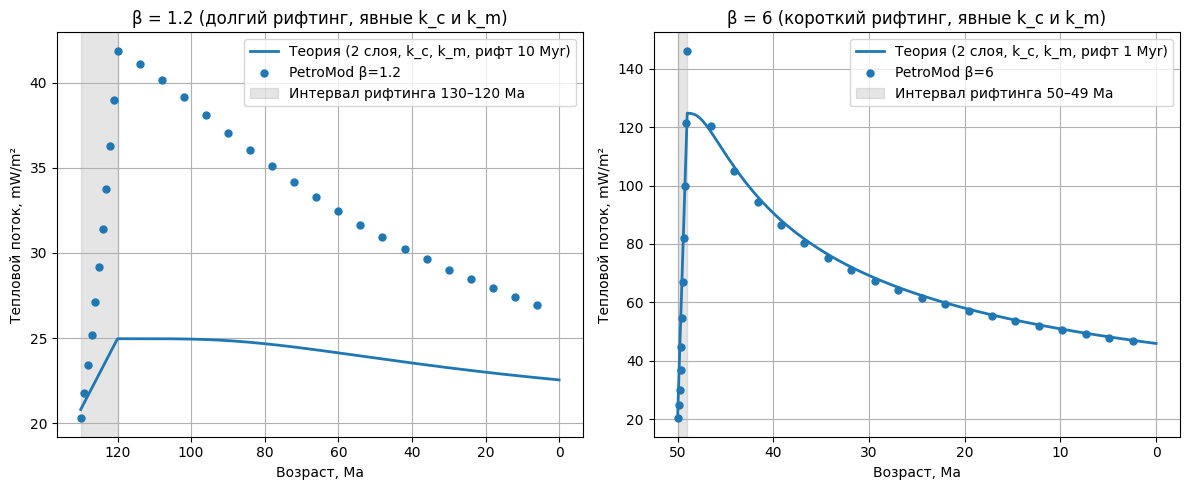

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. ФИЗИЧЕСКИЕ ПАРАМЕТРЫ, ГДЕ МОЖНО ЯВНО ЗАДАТЬ k КОРЫ И МАНТИИ
# ============================================================

# --- толщина слоёв ---
t_crust_km  = 30.0   # толщина коры, км
t_mantle_km = 95.0   # толщина литосферной мантии (до LAB), км

# --- теплопроводности ---
k_crust  = 2.0       # W/m/K
k_mantle = 2.0       # W/m/K

# --- плотность и теплоёмкость (можно тоже менять) ---
rho_crust,  cp_crust  = 2800.0, 1000.0   # кг/м3, Дж/кг/К
rho_mantle, cp_mantle = 3300.0, 1000.0

# --- температуры ---
T_surf = 0.0         # °C
T_m    = 1300.0      # температура на LAB, °C (можно варьировать)

# Переводы единиц
t_crust_m  = t_crust_km  * 1e3
t_mantle_m = t_mantle_km * 1e3
a_m        = t_crust_m + t_mantle_m  # общая толщина литосферы, м

# --- стационарный дорифтовый тепловой поток для двух слоёв ---
# q0 = (T_m - T_surf) / ( t_crust/k_crust + t_mantle/k_mantle )
q0_two_layer = (T_m - T_surf) / (t_crust_m / k_crust + t_mantle_m / k_mantle)  # W/m2
q0_two_layer_mW = q0_two_layer * 1e3  # mW/m2

print("Теоретический дорифтовый поток q0 (2 слоя) =", q0_two_layer_mW, "mW/m^2")

# --- термодиффузии и tau ---
kappa_crust  = k_crust  / (rho_crust  * cp_crust)   # м^2/с
kappa_mantle = k_mantle / (rho_mantle * cp_mantle) # м^2/с

# Для tau возьмём мантии (глубокий слой задаёт основной масштаб времени)
tau_sec = a_m**2 / (np.pi**2 * kappa_mantle)  # с
sec_per_myr = 1e6 * 365.25 * 24 * 3600
tau_myr = tau_sec / sec_per_myr
print("Тепловое время τ ≈", tau_myr, "Myr")

# ============================================================
# 1. МАККЕНЗИ С КОНЕЧНЫМ ВРЕМЕНЕМ РИФТИНГА (β(t) ЛИНЕЙНО РАСТЁТ)

def mckenzie_q_over_q0_finite_t(t, beta_final, T_rift, tau_myr, n_terms=20):
    """
    Теория МакКензи для РАСТЯНУТОГО во времени рифтинга.
    t       : время с МОМЕНТА НАЧАЛА рифта, Myr (может быть массив).
              t=0 — начало рифта, t=T_rift — конец рифта.
    beta_final : конечное β (после рифта).
    T_rift  : длительность рифтинга, Myr.
    tau_myr : τ литосферы, Myr, сюда уже вошли k и κ.
    n_terms : число гармоник.
    Возвращает q(t)/q0.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta_final * np.sin(n * np.pi / beta_final) / (n * np.pi)
    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # идёт рифтинг
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # пост-рифт
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age(age_array, age_start_rift, age_end_rift,
                          beta_final, tau_myr, q0, n_terms=200):
    """
    Обёртка в ОСИ ВОЗРАСТА (Ma).
    age_array     : массив возрастов (Ma, больше — старше)
    age_start_rift: возраст начала рифта (напр. 130 Ma)
    age_end_rift  : возраст конца рифта (напр. 120 Ma)
    beta_final    : конечное β
    tau_myr       : τ, Myr (из kappa)
    q0            : дорифтовый поток (W/m^2 ИЛИ mW/m^2 — но дальше везде
                     единицы должны быть одинаковы!)
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: tm = 0 при age=age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t(
            t_from_start[mask], beta_final, T_rift, tau_myr, n_terms=n_terms
        )

    return q0 * q_over_q0  # единицы те же, что у q0


# ============================================================
# 2. ДАННЫЕ PETROMOD (β=3 и β=6)

# --- кейс 1: β=1ю2, рифтинг 130–120 Ma ---
ages1 = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102, 96, 90, 84, 78, 72, 66, 60, 54,
     48, 42, 36, 30, 24, 18, 12,  6
], dtype=float)

q1_mW = np.array([
    20.28,21.79,23.43,25.20,27.11,29.17,31.39,33.76,36.30,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,31.67,
    30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)

age_start1 = 130.0
age_end1   = 120.0
beta1      = 1.2

# --- кейс 2: β=6, рифтинг 50–49 Ma ---
ages2 = np.array([
    50.00,49.90,49.80,49.70,49.60,49.50,49.40,49.30,49.20,49.10,49.00,
    46.55,44.10,41.65,39.20,36.75,34.30,31.85,29.40,26.95,24.50,22.05,
    19.60,17.15,14.70,12.25, 9.80, 7.35, 4.90, 2.45
], dtype=float)

q2_mW = np.array([
    20.28, 24.70, 30.10, 36.71, 44.81, 54.78, 67.03, 81.98,100.01,121.38,146.18,
   120.40,104.86, 94.24, 86.34, 80.16, 75.14, 70.95, 67.40, 64.33, 61.64, 59.27,
    57.14, 55.24, 53.51, 51.93, 50.48, 49.15, 47.92, 46.78
], dtype=float)

age_start2 = 50.0
age_end2   = 49.0
beta2      = 6.0

# ============================================================
# 3. ВЫБОР q0 ДЛЯ ТЕОРИИ

# Вариант 1 (физический): использовать q0 из двухслойной стационарной модели (из k_c, k_m)
q0_theor_mW = q0_two_layer_mW

# Вариант 2 (если хочешь идеально "приклеиться" к PetroMod):
# q0_theor_mW = q1_mW[0]  # для кейса 1, или q2_mW[0] для 2

print("q0, который идёт в теорию =", q0_theor_mW, "mW/m^2")

# ============================================================
# 4. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ (β=1.2 и β=6) С ЯВНОЙ ЗАВИСИМОСТЬЮ ОТ k

age_grid1 = np.linspace(130, 0, 600)  # для β=3
age_grid2 = np.linspace(50,  0, 700)  # для β=6

q1_theor_mW = mckenzie_q_finite_age(
    age_grid1,
    age_start_rift=age_start1,
    age_end_rift=age_end1,
    beta_final=beta1,
    tau_myr=tau_myr,
    q0=q0_theor_mW,
    n_terms=200
)

q2_theor_mW = mckenzie_q_finite_age(
    age_grid2,
    age_start_rift=age_start2,
    age_end_rift=age_end2,
    beta_final=beta2,
    tau_myr=tau_myr,
    q0=q0_theor_mW,   # тот же q0, т.к. та же литосфера до рифта
    n_terms=200
)
# ============================================================
# 5. ГРАФИКИ

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- левый: β=3, рифт 130–120 Ma ---
ax = axes[0]
ax.plot(age_grid1, q1_theor_mW, label='Теория (2 слоя, k_c, k_m, рифт 10 Myr)', lw=2)
ax.scatter(ages1, q1_mW, label='PetroMod β=1.2', s=25, zorder=3)

ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label='Интервал рифтинга 130–120 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 1.2 (долгий рифтинг, явные k_c и k_m)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- правый: β=6, рифт 50–49 Ma ---
ax = axes[1]
ax.plot(age_grid2, q2_theor_mW, label='Теория (2 слоя, k_c, k_m, рифт 1 Myr)', lw=2)
ax.scatter(ages2, q2_mW, label='PetroMod β=6', s=25, zorder=3)

ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label='Интервал рифтинга 50–49 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 6 (короткий рифтинг, явные k_c и k_m)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()



## 0. Обозначения и параметры

Толщины слоёв:

$$
t_c \;-\; \text{толщина коры}, \qquad
t_m \;-\; \text{толщина литосферной мантии},
$$

$$
a = t_c + t_m \;-\; \text{общая толщина литосферы}.
$$

Теплопроводности и диффузивности:

$$
k_c,\; k_m \;-\; \text{теплопроводность коры и мантии},
$$

$$
\rho_c, c_{p,c},\; \rho_m, c_{p,m} \;-\; \text{плотность и теплоёмкость},
$$

$$
\kappa_c = \frac{k_c}{\rho_c c_{p,c}}, \qquad
\kappa_m = \frac{k_m}{\rho_m c_{p,m}}.
$$

Эффективная диффузивность и характерное время:

$$
\kappa_{\text{eff}} =
\frac{\kappa_c t_c + \kappa_m t_m}{t_c + t_m},
$$

$$
\tau = \frac{a^2}{\pi^2 \kappa_{\text{eff}}}, \qquad
\tau_n = \frac{\tau}{n^2}.
$$

Граничные температуры:

$$
T_s \;-\; \text{температура поверхности}, \qquad
T_m \;-\; \text{температура на LAB}.
$$

Коэффициент растяжения и длительность рифтинга:

$$
\beta = \beta_{\text{final}}, \qquad
T_{\text{rift}} \;-\; \text{длительность рифтинга},
$$

спектр МакКензи:

$$
A_n(\beta) = 2\beta \,\frac{\sin\!\left(\dfrac{n\pi}{\beta}\right)}{n\pi}.
$$

---

## 1. До рифтинга

### 1.1. Дорифтовый тепловой поток \(q_0\) (2-слойная литосфера)

$$
q_0
=
\frac{T_m - T_s}{\dfrac{t_c}{k_c} + \dfrac{t_m}{k_m}}.
\tag{1}
$$

До начала растяжения (стационарное состояние):

$$
q(t) = q_0,
\qquad t \le 0.
\tag{2}
$$

---

## 2. Во время рифтинга (равномерный рифтинг, линейный рост \(\beta(t)\))

Время отсчитываем от **начала** рифтинга:

\(t = 0\) — начало рифтинга;
\(t = T_{\{rift}}\) — конец рифтинга.

При \(0 < t < T_{\{rift}}\) тепловой поток в безразмерной форме \(q(t)/q_0\):

$$
\frac{q(t)}{q_0}
=
1 +
\sum_{n=1}^{\infty}
A_n(\beta)\,
\frac{\tau_n}{T_{\text{rift}}}
\left[
1 - \exp\!\left(-\frac{t}{\tau_n}\right)
\right],
\qquad 0 < t < T_{\text{rift}}.
\tag{3}
$$

Где

$$
A_n(\beta) = 2\beta\,\frac{\sin\!\left(\dfrac{n\pi}{\beta}\right)}{n\pi},
\qquad
\tau_n = \frac{\tau}{n^2}, \quad
\tau = \frac{a^2}{\pi^2 \kappa_{\text{eff}}}.
\tag{4}
$$

Полный тепловой поток:

$$
q(t) = q_0 \,\frac{q(t)}{q_0}.
\tag{5}
$$

(Формула (5) просто говорит, что мы масштабируем безразмерный результат на \(q_0\).)

---

## 3. После рифтинга (пост-рифт)

После окончания рифтинга \(t \ge T_{\text{rift}}\) (всё растяжение уже произошло):

$$
\frac{q(t)}{q_0}
=
1 +
\sum_{n=1}^{\infty}
A_n(\beta)\,
\frac{\tau_n}{T_{\text{rift}}}
\left[
\exp\!\left(-\frac{t - T_{\text{rift}}}{\tau_n}\right)
-
\exp\!\left(-\frac{t}{\tau_n}\right)
\right],
\qquad t \ge T_{\text{rift}}.
\tag{6}
$$

И снова:

$$
q(t) = q_0 \,\frac{q(t)}{q_0}.
\tag{7}
$$

---

## 4. Связь времени \(t\) с возрастом \(Age\)

Для удобства сопоставления с PetroMod обычно работаем не со временем вперёд, а с возрастом (Ma).

Пусть:

- \(Age_{\text{start}}\) — возраст начала рифтинга (например, \(130\,\text{Ma}\)),
- \(Age_{\text{end}}\) — возраст конца рифтинга (например, \(120\,\text{Ma}\)),

тогда длительность рифтинга:

$$
T_{\text{rift}} = Age_{\text{start}} - Age_{\text{end}}.
\tag{8}
$$

Для произвольного возраста \(Age\) время от начала рифтинга:

$$
t(Age) = Age_{\text{start}} - Age.
\tag{9}
$$

Тогда фазу определяем так:

- если \(Age > Age_{\text{start}}\) ⇒ \(t < 0\) ⇒ **до рифтинга**, используем (2);
- если \(Age_{\text{end}} < Age \le Age_{\text{start}}\) ⇒ \(0 \le t \le T_{\text{rift}}\) ⇒ **во время рифтинга**, используем (3);
- если \(Age \le Age_{\text{end}}\) ⇒ \(t \ge T_{\text{rift}}\) ⇒ **после рифтинга**, используем (6).

Полный поток через возраст:

$$
q(Age) = q\bigl(t(Age)\bigr).
\tag{10}
$$
```


Дорифтовый поток q0 (2 слоя) = 20.960800000000003 mW/m^2
Термодиффузии: κ_c = 6.26590330788804e-07 м²/с, κ_m = 5.295698924731182e-07 м²/с
Эффективная κ_eff = 5.528547976688828e-07 м²/с  →  τ ≈ 90.74134887614228 Myr
q0, который используется в теории = 20.960800000000003 mW/m^2


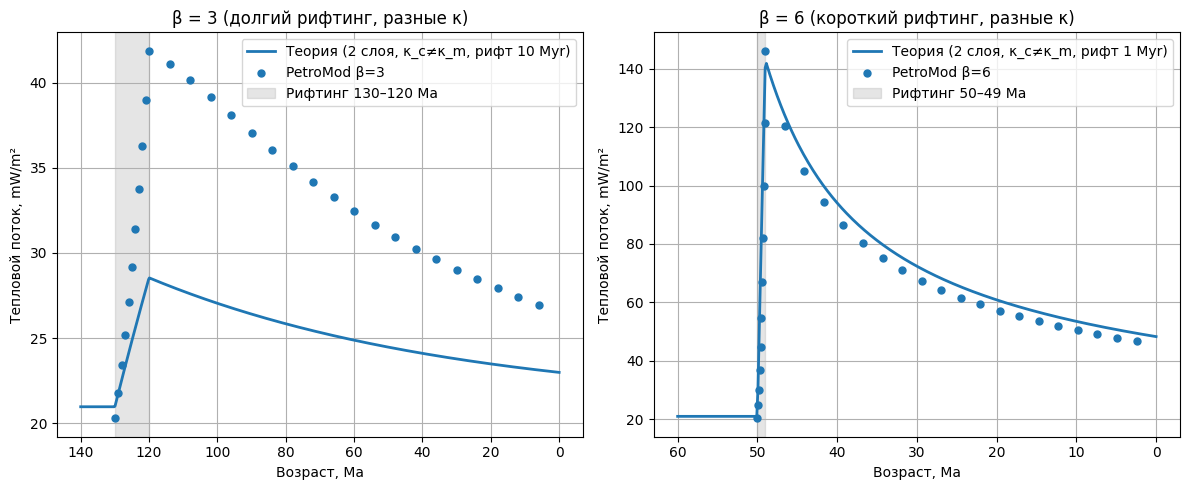

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. ПАРАМЕТРЫ: ТЕПЛОПРОВОДНОСТЬ И ДИФФУЗИВНОСТЬ КОРЫ И МАНТИИ
# ============================================================

# --- толщина слоёв ---
t_crust_km  = 30.0   # толщина коры, км
t_mantle_km = 95.0   # толщина литосферной мантии, км

# --- теплопроводности (явно задаём для коры и мантии) ---
k_crust  = 1.97       # W/m/K
k_mantle = 1.97       # W/m/K

# --- плотность и теплоёмкость (можно менять отдельно) ---
rho_crust,  cp_crust  = 2620.0, 1200.0   # кг/м3, Дж/кг/К
rho_mantle, cp_mantle = 3100.0, 1200.0

# --- температуры ---
T_surf = 0.0         # °C
T_m    = 1330.0      # температура на LAB, °C

# Перевод в метры
t_crust_m  = t_crust_km  * 1e3
t_mantle_m = t_mantle_km * 1e3
a_m        = t_crust_m + t_mantle_m   # общая толщина литосферы, м

# ============================================================
# 1. ДОРИФТОВЫЙ ПОТОК ДЛЯ ДВУХСЛОЙНОЙ ЛИТОСФЕРЫ
# ============================================================

# q0 = (T_m - T_surf) / (t_c/k_c + t_m/k_m)
q0_two_layer = (T_m - T_surf) / (t_crust_m / k_crust + t_mantle_m / k_mantle)  # W/m2
q0_two_layer_mW = q0_two_layer * 1e3  # mW/m2

print("Дорифтовый поток q0 (2 слоя) =", q0_two_layer_mW, "mW/m^2")

# ============================================================
# 2. РАЗНЫЕ ДИФФУЗИВНОСТИ КОРЫ И МАНТИИ → ЭФФЕКТИВНАЯ κ_eff
# ============================================================

# Термодиффузии слоёв
kappa_crust  = k_crust  / (rho_crust  * cp_crust)   # м^2/с
kappa_mantle = k_mantle / (rho_mantle * cp_mantle) # м^2/с

# Эффективная диффузивность для всей литосферы
# (толщинно-взвешенное среднее: κ_eff ≈ (κ_c * t_c + κ_m * t_m) / (t_c + t_m))
kappa_eff = (kappa_crust * t_crust_m + kappa_mantle * t_mantle_m) / a_m

# Масштабное тепловое время τ для "эквивалентного однородного слоя"
tau_sec = a_m**2 / (np.pi**2 * kappa_eff)
sec_per_myr = 1e6 * 365.25 * 24 * 3600
tau_myr = tau_sec / sec_per_myr

print("Термодиффузии: κ_c =", kappa_crust, "м²/с, κ_m =", kappa_mantle, "м²/с")
print("Эффективная κ_eff =", kappa_eff, "м²/с  →  τ ≈", tau_myr, "Myr")

# ============================================================
# 3. МАККЕНЗИ С КОНЕЧНЫМ ВРЕМЕНЕМ РИФТИНГА (β(t) ЛИНЕЙНО)
# ============================================================

def mckenzie_q_over_q0_finite_t(t, beta_final, T_rift, tau_myr, n_terms=200):
    """
    МакКензи с растянутым во времени рифтингом.
    t        : время с начала рифта, Myr (0 → начало, T_rift → конец).
    beta_final : конечное β.
    T_rift   : длительность рифтинга, Myr.
    tau_myr  : τ для эквивалентной литосферы (на базе κ_eff).
    n_terms  : число гармоник.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    # спектр МакКензи
    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta_final * np.sin(n * np.pi / beta_final) / (n * np.pi)
    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age(age_array, age_start_rift, age_end_rift,
                          beta_final, tau_myr, q0, n_terms=200):
    """
    То же самое, но в шкале возрастов (Ma).
    age_array      : массив возрастов.
    age_start_rift : возраст начала рифта.
    age_end_rift   : возраст конца рифта.
    beta_final     : конечное β.
    tau_myr        : τ (из κ_eff).
    q0             : дорифтовый поток (mW/m² или W/m² — консистентно).
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: t = 0 при age = age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t(
            t_from_start[mask], beta_final, T_rift, tau_myr, n_terms=n_terms
        )

    return q0 * q_over_q0

# ============================================================
# 4. ДАННЫЕ PETROMOD
# ============================================================

# --- кейс 1: β = 1.2, рифтинг 130–120 Ma ---
ages1 = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102, 96, 90, 84, 78, 72, 66, 60, 54,
     48, 42, 36, 30, 24, 18, 12,  6
], dtype=float)

q1_mW = np.array([
    20.28,21.79,23.43,25.20,27.11,29.17,31.39,33.76,36.30,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,31.67,
    30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)

age_start1 = 130.0
age_end1   = 120.0
beta1      = 1.2

# --- кейс 2: β = 6, рифтинг 50–49 Ma ---
ages2 = np.array([
    50.00,49.90,49.80,49.70,49.60,49.50,49.40,49.30,49.20,49.10,49.00,
    46.55,44.10,41.65,39.20,36.75,34.30,31.85,29.40,26.95,24.50,22.05,
    19.60,17.15,14.70,12.25, 9.80, 7.35, 4.90, 2.45
], dtype=float)

q2_mW = np.array([
    20.28, 24.70, 30.10, 36.71, 44.81, 54.78, 67.03, 81.98,100.01,121.38,146.18,
   120.40,104.86, 94.24, 86.34, 80.16, 75.14, 70.95, 67.40, 64.33, 61.64, 59.27,
    57.14, 55.24, 53.51, 51.93, 50.48, 49.15, 47.92, 46.78
], dtype=float)

age_start2 = 50.0
age_end2   = 49.0
beta2      = 6.0

# ============================================================
# 5. ВЫБОР q0 ДЛЯ ТЕОРИИ
# ============================================================

# Физически корректный вариант: q0 из двухслойной теплопроводности
q0_theor_mW = q0_two_layer_mW

# (Если хочешь "приклеиться" к PetroMod, можно сделать q0_theor_mW = 20.28)

print("q0, который используется в теории =", q0_theor_mW, "mW/m^2")

# ============================================================
# 6. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ (β=3 и β=6, κ_c ≠ κ_m)
# ============================================================

age_grid1 = np.linspace(140, 0, 600)  # для β=3
age_grid2 = np.linspace(60,  0, 400)  # для β=6

q1_theor_mW = mckenzie_q_finite_age(
    age_grid1, age_start1, age_end1, beta1, tau_myr, q0_theor_mW, n_terms=1
)

q2_theor_mW = mckenzie_q_finite_age(
    age_grid2, age_start2, age_end2, beta2, tau_myr, q0_theor_mW, n_terms=5
)

# ============================================================
# 7. ГРАФИКИ
# ============================================================

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- β=3 ---
ax = axes[0]
ax.plot(age_grid1, q1_theor_mW, label='Теория (2 слоя, κ_c≠κ_m, рифт 10 Myr)', lw=2)
ax.scatter(ages1, q1_mW, label='PetroMod β=3', s=25, zorder=3)
ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label='Рифтинг 130–120 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 3 (долгий рифтинг, разные κ)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- β=6 ---
ax = axes[1]
ax.plot(age_grid2, q2_theor_mW, label='Теория (2 слоя, κ_c≠κ_m, рифт 1 Myr)', lw=2)
ax.scatter(ages2, q2_mW, label='PetroMod β=6', s=25, zorder=3)
ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label='Рифтинг 50–49 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title('β = 6 (короткий рифтинг, разные κ)')
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


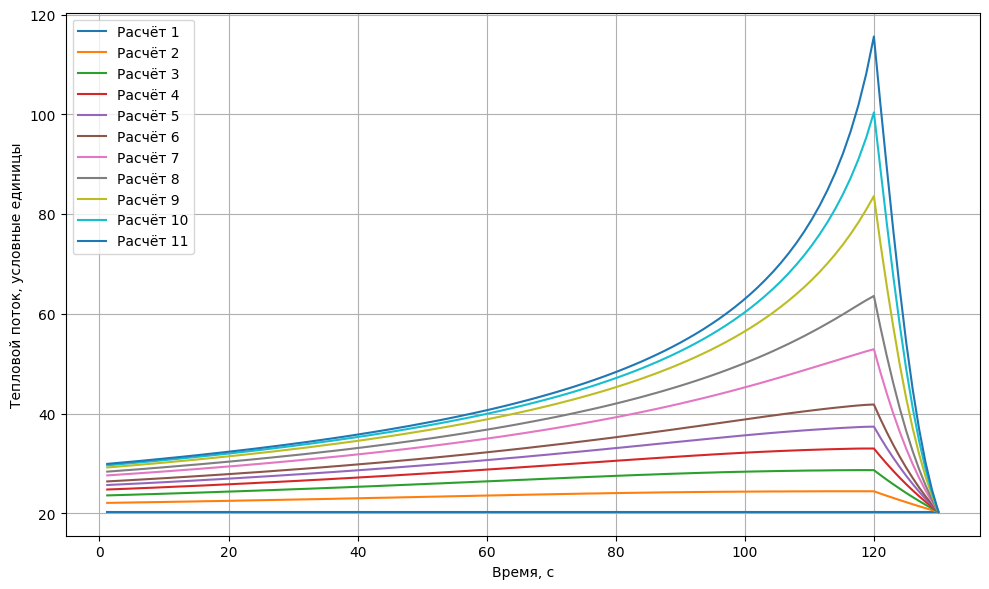

In [148]:
import matplotlib.pyplot as plt

MAX_CALC = 22  # всего расчётов в таблице

# списки для данных: на каждый расчёт – свой список времени и теплового потока
times = [[] for _ in range(MAX_CALC)]
fluxes = [[] for _ in range(MAX_CALC)]

with open("data.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue  # пустые строки пропускаем

        # если вдруг оставите строку с "Расчет 1  Расчет 2 ..." – просто пропустим её
        if line.startswith("Расчет") or line.startswith("расчет"):
            continue

        # заменяем запятую на точку, чтобы float() понял числа
        line = line.replace(",", ".")
        parts = line.split()

        # в строке должны быть пары чисел: (t1, q1, t2, q2, ..., t22, q22)
        if len(parts) % 2 != 0:
            print("Странная строка, пропускаю:\n", line)
            continue

        for i in range(0, len(parts), 2):
            col = i // 2           # номер расчёта (0..21)
            if col >= MAX_CALC:
                break
            t = float(parts[i])
            q = float(parts[i + 1])
            times[col].append(t)
            fluxes[col].append(q)

# ---- ВЫБОР, КАКИЕ РАСЧЁТЫ ВИЗУАЛИЗИРОВА ----

# первые 11 расчётов (1..11):
cols_to_plot = list(range(0, 11))

# вторые 11 расчётов (12..22):
# cols_to_plot = list(range(11, 22))

#  конкретные расчёты: 1, 4, 5
# cols_to_plot = [0, 3, 4]   # индексы = номер расчёта - 1

# Построение графиков
plt.figure(figsize=(10, 6))

for col in cols_to_plot:
    plt.plot(times[col], fluxes[col], label=f"Расчёт {col+1}")

plt.xlabel("Время, с")
plt.ylabel("Тепловой поток, условные единицы")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Дорифтовый поток q0 (2 слоя) = 20.290480000000002 mW/m^2
Термодиффузии: κ_c = 6.065521628498728e-07 м²/с, κ_m = 5.126344086021506e-07 м²/с
Эффективная κ_eff = 5.35174669621604e-07 м²/с  →  τ ≈ 93.7390966366021 Myr
q0, который используется в теории = 20.290480000000002 mW/m^2


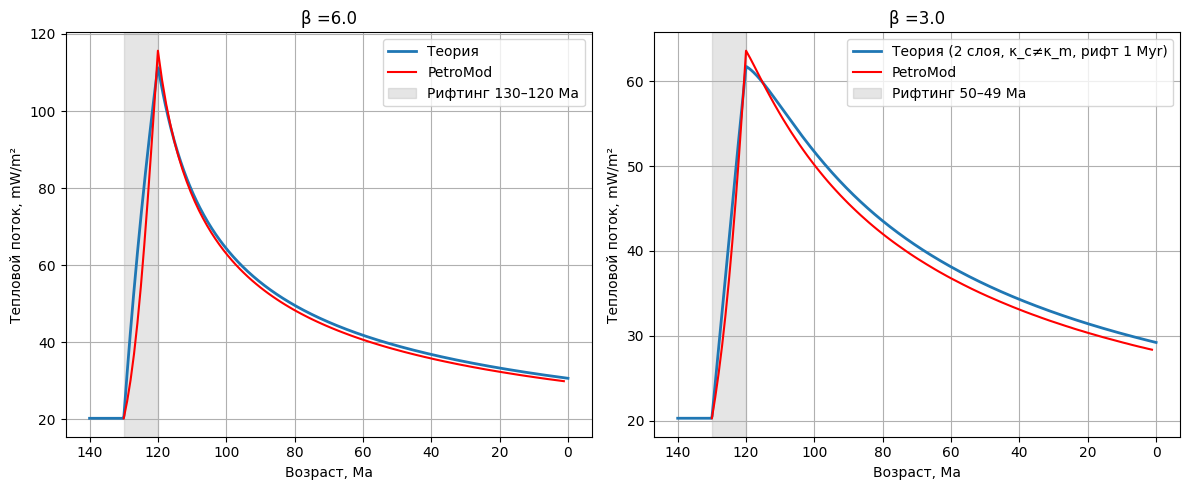

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. ПАРАМЕТРЫ: ТЕПЛОПРОВОДНОСТЬ И ДИФФУЗИВНОСТЬ КОРЫ И МАНТИИ
# ============================================================

# --- толщина слоёв ---
t_crust_km  = 30.0   # толщина коры, км
t_mantle_km = 95.0   # толщина литосферной мантии, км

# --- теплопроводности (явно задаём для коры и мантии) ---
k_crust  = 1.907      # W/m/K
k_mantle = 1.907       # W/m/K

# --- плотность и теплоёмкость (можно менять отдельно) ---
rho_crust,  cp_crust  = 2620.0, 1200.0   # кг/м3, Дж/кг/К
rho_mantle, cp_mantle = 3100.0, 1200.0

# --- температуры ---
T_surf = 0.0         # °C
T_m    = 1330.0      # температура на LAB, °C

# Перевод в метры
t_crust_m  = t_crust_km  * 1e3
t_mantle_m = t_mantle_km * 1e3
a_m        = t_crust_m + t_mantle_m   # общая толщина литосферы, м

# ============================================================
# 1. ДОРИФТОВЫЙ ПОТОК ДЛЯ ДВУХСЛОЙНОЙ ЛИТОСФЕРЫ
# ============================================================

# q0 = (T_m - T_surf) / (t_c/k_c + t_m/k_m)
q0_two_layer = (T_m - T_surf) / (t_crust_m / k_crust + t_mantle_m / k_mantle)  # W/m2
q0_two_layer_mW = q0_two_layer * 1e3  # mW/m2

print("Дорифтовый поток q0 (2 слоя) =", q0_two_layer_mW, "mW/m^2")

# ============================================================
# 2. РАЗНЫЕ ДИФФУЗИВНОСТИ КОРЫ И МАНТИИ → ЭФФЕКТИВНАЯ κ_eff
# ============================================================

# Термодиффузии слоёв
kappa_crust  = k_crust  / (rho_crust  * cp_crust)   # м^2/с
kappa_mantle = k_mantle / (rho_mantle * cp_mantle) # м^2/с

# Эффективная диффузивность для всей литосферы
# (толщинно-взвешенное среднее: κ_eff ≈ (κ_c * t_c + κ_m * t_m) / (t_c + t_m))
kappa_eff = (kappa_crust * t_crust_m + kappa_mantle * t_mantle_m) / a_m

# Масштабное тепловое время τ для "эквивалентного однородного слоя"
tau_sec = a_m**2 / (np.pi**2 * kappa_eff)
sec_per_myr = 1e6 * 365.25 * 24 * 3600
tau_myr = tau_sec / sec_per_myr

print("Термодиффузии: κ_c =", kappa_crust, "м²/с, κ_m =", kappa_mantle, "м²/с")
print("Эффективная κ_eff =", kappa_eff, "м²/с  →  τ ≈", tau_myr, "Myr")

# ============================================================
# 3. МАККЕНЗИ С КОНЕЧНЫМ ВРЕМЕНЕМ РИФТИНГА (β(t) ЛИНЕЙНО)
# ============================================================

def mckenzie_q_over_q0_finite_t(t, beta_final, T_rift, tau_myr, n_terms=200):
    """
    МакКензи с растянутым во времени рифтингом.
    t        : время с начала рифта, Myr (0 → начало, T_rift → конец).
    beta_final : конечное β.
    T_rift   : длительность рифтинга, Myr.
    tau_myr  : τ для эквивалентной литосферы (на базе κ_eff).
    n_terms  : число гармоник.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    # спектр МакКензи
    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta_final * np.sin(n * np.pi / beta_final) / (n * np.pi)
    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age(age_array, age_start_rift, age_end_rift,
                          beta_final, tau_myr, q0, n_terms=200):
    """
    То же самое, но в шкале возрастов (Ma).
    age_array      : массив возрастов.
    age_start_rift : возраст начала рифта.
    age_end_rift   : возраст конца рифта.
    beta_final     : конечное β.
    tau_myr        : τ (из κ_eff).
    q0             : дорифтовый поток (mW/m² или W/m² — консистентно).
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: t = 0 при age = age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t(
            t_from_start[mask], beta_final, T_rift, tau_myr, n_terms=n_terms
        )

    return q0 * q_over_q0

# ============================================================
# 4. ДАННЫЕ PETROMOD
# ============================================================

# --- кейс 1: рифтинг 130–120 Ma ---
ages1: list[float] = []
q1_mW: list[float] = []


# def calculate_average(ages: list[float]) -> float:
#     return sum(ages) / len(ages) if ages else 0.0

cols_to_plot = [10]
for col in cols_to_plot:
    ages1 = times[col] 
    q1_mW = fluxes[col]

age_start1 = 130.0
age_end1   = 120.0
beta1      = 6.0

# --- кейс 2: β = 3, рифтинг 130–120 Ma ---
ages2: list[float] = []
q2_mW: list[float] = []
cols_to_plot = [7] #<-- расчет - 1
for col in cols_to_plot:
    ages2 = times[col] 
    q2_mW = fluxes[col]

age_start2 = 130.0
age_end2   = 120.0
beta2      = 3.0

# ============================================================
# 5. ВЫБОР q0 ДЛЯ ТЕОРИИ
# ============================================================

# Физически корректный вариант: q0 из двухслойной теплопроводности
q0_theor_mW = q0_two_layer_mW

# (Если хочешь "приклеиться" к PetroMod, можно сделать q0_theor_mW = 20.28)

print("q0, который используется в теории =", q0_theor_mW, "mW/m^2")

# ============================================================
# 6. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ (β=3 и β=6, κ_c ≠ κ_m)
# ============================================================

age_grid1 = np.linspace(140, 0, 600)  
age_grid2 = np.linspace(140, 0, 600)  

q1_theor_mW = mckenzie_q_finite_age(
    age_grid1, age_start1, age_end1, beta1, tau_myr, q0_theor_mW, n_terms=5
)

q2_theor_mW = mckenzie_q_finite_age(
    age_grid2, age_start2, age_end2, beta2, tau_myr, q0_theor_mW, n_terms=4
)

# ============================================================
# 7. ГРАФИКИ
# ============================================================

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- β=3 ---
ax = axes[0]
ax.plot(age_grid1, q1_theor_mW, label='Теория', lw=2)
ax.plot(ages1, q1_mW, label='PetroMod', color='red')
ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label='Рифтинг 130–120 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β ={beta1}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- β=6 ---
ax = axes[1]
ax.plot(age_grid2, q2_theor_mW, label='Теория (2 слоя, κ_c≠κ_m, рифт 1 Myr)', lw=2)
ax.plot(ages2, q2_mW, label='PetroMod', color='red')
ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label='Рифтинг 50–49 Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β ={beta2}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("comparison_petromod_theory.png", dpi=300)
plt.show()


In [100]:
import numpy as np

# ---------- 1. Вспомогательные функции ----------

def compute_q0(t_c, t_m, k_c, k_m, T_s, T_m):
    """
    Дорифтовый поток q0 для двухслойной литосферы.
    t_c, t_m в метрах; k_c, k_m в W/m/K; T_s, T_m в °C.
    """
    return (T_m - T_s) / (t_c / k_c + t_m / k_m)  # W/m2

def compute_tau(t_c, t_m, k_c, k_m, rho_c, cp_c, rho_m, cp_m):
    """
    Эффективная диффузивность kappa_eff и характерное время tau (Myr).
    """
    t_c = float(t_c)
    t_m = float(t_m)
    a = t_c + t_m

    kappa_c = k_c / (rho_c * cp_c)
    kappa_m = k_m / (rho_m * cp_m)

    kappa_eff = (kappa_c * t_c + kappa_m * t_m) / a

    tau_sec = a**2 / (np.pi**2 * kappa_eff)
    sec_per_myr = 1e6 * 365.25 * 24 * 3600
    tau_myr = tau_sec / sec_per_myr
    return tau_myr, kappa_eff

def q_over_q0_finite_t(t, beta, T_rift, tau_myr, n_terms=200):
    """
    q(t)/q0 при конечном времени рифтинга.
    t (Myr) от начала рифта (0 -> start, T_rift -> end).
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta * np.sin(n * np.pi / beta) / (n * np.pi)
    tau_n = tau_myr / (n**2)

    for i, ti in enumerate(t):
        if ti <= 0:
            # до начала рифта
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


# ---------- 2. Базовые параметры (можешь менять под себя) ----------

# Геометрия
t_c_km  = 30.0   # км
t_m_km  = 95.0   # км

t_c = t_c_km * 1e3   # м
t_m = t_m_km * 1e3   # м

# Теплопроводности
k_c = 2.5  # W/m/K
k_m = 3.0  # W/m/K

# Плотности и теплоёмкости
rho_c, cp_c = 2800.0, 1000.0
rho_m, cp_m = 3300.0, 1000.0

# Температуры
T_s = 0.0
T_m_val = 1300.0

# Рифтинг
beta = 3.0          # можешь попробовать 6.0
T_rift = 10.0       # Myr (например, 10 Myr или 1 Myr)

# ---------- 3. Вычисляем базовые q0 и tau ----------

q0 = compute_q0(t_c, t_m, k_c, k_m, T_s, T_m_val)   # W/m2
tau_myr, kappa_eff = compute_tau(t_c, t_m, k_c, k_m, rho_c, cp_c, rho_m, cp_m)

# Характерные моменты времени в шкале t с начала рифта
t_pre   = -1.0               # до рифта (любое t < 0)
t_end   = T_rift             # конец рифтинга
t_post  = T_rift + tau_myr   # через tau после конца рифта

# Характерные значения теплового потока
q_pre        = q0                            # до рифта
q_rift_end   = q0 * q_over_q0_finite_t(t_end,  beta, T_rift, tau_myr)
q_post_tau   = q0 * q_over_q0_finite_t(t_post, beta, T_rift, tau_myr)

print("Базовые значения (W/m^2):")
print(f"  q_pre      = {q_pre:.4e}")
print(f"  q_rift_end = {q_rift_end:.4e}")
print(f"  q_post_tau = {q_post_tau:.4e}")
print(f"  tau        = {tau_myr:.2f} Myr\n")


# ---------- 4. Анализ чувствительности: +/- 10% ----------

def perturb_and_report(name, rel_change, **param_overrides):
    """
    Меняем один параметр на rel_change (например, +0.1 или -0.1)
    и пересчитываем три q.
    """
    # Берём текущие значения как baseline
    t_c_loc, t_m_loc = t_c, t_m
    k_c_loc, k_m_loc = k_c, k_m
    rho_c_loc, cp_c_loc = rho_c, cp_c
    rho_m_loc, cp_m_loc = rho_m, cp_m
    T_s_loc, T_m_loc = T_s, T_m_val
    beta_loc, T_rift_loc = beta, T_rift

    # Переопределяем, если нужно
    if "t_c" in param_overrides:
        t_c_loc = t_c * (1 + rel_change)
    if "t_m" in param_overrides:
        t_m_loc = t_m * (1 + rel_change)
    if "k_c" in param_overrides:
        k_c_loc = k_c * (1 + rel_change)
    if "k_m" in param_overrides:
        k_m_loc = k_m * (1 + rel_change)
    if "T_m" in param_overrides:
        T_m_loc = T_m_val * (1 + rel_change)
    if "beta" in param_overrides:
        beta_loc = beta * (1 + rel_change)
    if "T_rift" in param_overrides:
        T_rift_loc = T_rift * (1 + rel_change)

    # Пересчёт q0 и tau
    q0_loc = compute_q0(t_c_loc, t_m_loc, k_c_loc, k_m_loc, T_s_loc, T_m_loc)
    tau_loc, _ = compute_tau(t_c_loc, t_m_loc, k_c_loc, k_m_loc,
                             rho_c_loc, cp_c_loc, rho_m_loc, cp_m_loc)

    # Новые характерные моменты
    t_end_loc  = T_rift_loc
    t_post_loc = T_rift_loc + tau_loc

    # Новые q
    q_pre_loc      = q0_loc
    q_rift_end_loc = q0_loc * q_over_q0_finite_t(t_end_loc,  beta_loc, T_rift_loc, tau_loc)
    q_post_tau_loc = q0_loc * q_over_q0_finite_t(t_post_loc, beta_loc, T_rift_loc, tau_loc)

    # Относительные изменения (в %)
    def rel_diff(new, old):
        return 100.0 * (new / old - 1.0)

    print(f"=== Параметр: {name}, изменение {rel_change*100:+.0f}% ===")
    print(f"  Δq_pre      = {rel_diff(q_pre_loc,      q_pre):+6.2f} %")
    print(f"  Δq_rift_end = {rel_diff(q_rift_end_loc, q_rift_end):+6.2f} %")
    print(f"  Δq_post_tau = {rel_diff(q_post_tau_loc, q_post_tau):+6.2f} %")
    print(f"  новая tau   = {tau_loc:.2f} Myr (Δ = {rel_diff(tau_loc, tau_myr):+6.2f} %)")
    print()


# Примеры: меняем каждый параметр на +10% и -10%

for rel in (+0.1, -0.1):
    perturb_and_report("t_c (толщина коры)", rel, t_c=True)
    perturb_and_report("t_m (толщина мантии)", rel, t_m=True)
    perturb_and_report("k_c (кору)", rel, k_c=True)
    perturb_and_report("k_m (мантию)", rel, k_m=True)
    perturb_and_report("T_m (подошва литосферы)", rel, T_m=True)
    perturb_and_report("beta (растяжение)", rel, beta=True)
    perturb_and_report("T_rift (длительность рифтинга)", rel, T_rift=True)


Базовые значения (W/m^2):
  q_pre      = 2.9771e-02
  q_rift_end = 8.7174e-02
  q_post_tau = 4.6667e-02
  tau        = 55.42 Myr

=== Параметр: t_c (толщина коры), изменение +10% ===
  Δq_pre      =  -2.67 %
  Δq_rift_end =  -2.41 %
  Δq_post_tau =  -2.52 %
  новая tau   = 58.13 Myr (Δ =  +4.89 %)

=== Параметр: t_m (толщина мантии), изменение +10% ===
  Δq_pre      =  -6.76 %
  Δq_rift_end =  -6.05 %
  Δq_post_tau =  -6.34 %
  новая tau   = 64.15 Myr (Δ = +15.74 %)

=== Параметр: k_c (кору), изменение +10% ===
  Δq_pre      =  +2.56 %
  Δq_rift_end =  +2.42 %
  Δq_post_tau =  +2.48 %
  новая tau   = 54.14 Myr (Δ =  -2.31 %)

=== Параметр: k_m (мантию), изменение +10% ===
  Δq_pre      =  +7.06 %
  Δq_rift_end =  +6.57 %
  Δq_post_tau =  +6.79 %
  новая tau   = 51.49 Myr (Δ =  -7.09 %)

=== Параметр: T_m (подошва литосферы), изменение +10% ===
  Δq_pre      = +10.00 %
  Δq_rift_end = +10.00 %
  Δq_post_tau = +10.00 %
  новая tau   = 55.42 Myr (Δ =  +0.00 %)

=== Параметр: beta (растяже

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Вспомогательные функции ----------

def compute_q0(t_c, t_m, k_c, k_m, T_s, T_m):
    """
    Дорифтовый поток q0 для двухслойной литосферы.
    t_c, t_m в метрах; k_c, k_m в W/m/K; T_s, T_m в °C.
    """
    return (T_m - T_s) / (t_c / k_c + t_m / k_m)  # W/m2


def compute_tau(t_c, t_m, k_c, k_m, rho_c, cp_c, rho_m, cp_m):
    """
    Эффективная диффузивность kappa_eff и характерное время tau (Myr).
    """
    t_c = float(t_c)
    t_m = float(t_m)
    a = t_c + t_m

    kappa_c = k_c / (rho_c * cp_c)
    kappa_m = k_m / (rho_m * cp_m)

    kappa_eff = (kappa_c * t_c + kappa_m * t_m) / a

    tau_sec = a**2 / (np.pi**2 * kappa_eff)
    sec_per_myr = 1e6 * 365.25 * 24 * 3600
    tau_myr = tau_sec / sec_per_myr
    return tau_myr, kappa_eff


def q_over_q0_finite_t(t, beta, T_rift, tau_myr, n_terms=200):
    """
    q(t)/q0 при конечном времени рифтинга.
    t (Myr) от начала рифта (0 -> start, T_rift -> end).
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta * np.sin(n * np.pi / beta) / (n * np.pi)
    tau_n = tau_myr / (n**2)

    for i, ti in enumerate(t):
        if ti <= 0:
            # до начала рифта
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


In [102]:
# ---------- Базовые параметры (можешь менять) ----------

# Геометрия
t_c_km  = 30.0   # толщина коры, км
t_m_km  = 95.0   # толщина мантии, км
t_c = t_c_km * 1e3
t_m = t_m_km * 1e3

# Теплопроводности
k_c = 2.5  # W/m/K
k_m = 3.0  # W/m/K

# Плотности и теплоёмкости
rho_c, cp_c = 2800.0, 1000.0
rho_m, cp_m = 3300.0, 1000.0

# Температуры
T_s = 0.0
T_m_val = 1300.0

# Параметры рифтинга
beta = 3.0      # попробуй ещё beta = 6.0
T_rift = 10.0   # Myr (например, 10 Myr или 1 Myr)

# ---------- Базовые q0 и tau ----------

q0 = compute_q0(t_c, t_m, k_c, k_m, T_s, T_m_val)   # W/m2
tau_myr, kappa_eff = compute_tau(t_c, t_m, k_c, k_m, rho_c, cp_c, rho_m, cp_m)

# Характерные моменты времени (от начала рифта)
t_pre   = -1.0               # до рифта (любое t < 0)
t_end   = T_rift             # конец рифтинга
t_post  = T_rift + tau_myr   # через tau после конца рифта

# Характерные значения теплового потока
q_pre        = q0                            # до рифта
q_rift_end   = q0 * q_over_q0_finite_t(t_end,  beta, T_rift, tau_myr)
q_post_tau   = q0 * q_over_q0_finite_t(t_post, beta, T_rift, tau_myr)

print("Базовые значения (W/m^2):")
print(f"  q_pre      = {q_pre:.4e}")
print(f"  q_rift_end = {q_rift_end:.4e}")
print(f"  q_post_tau = {q_post_tau:.4e}")
print(f"  tau        = {tau_myr:.2f} Myr")


Базовые значения (W/m^2):
  q_pre      = 2.9771e-02
  q_rift_end = 8.7174e-02
  q_post_tau = 4.6667e-02
  tau        = 55.42 Myr


In [104]:
# ---------- Анализ чувствительности: собираем данные ----------

params = [
    ("t_c (толщина коры)", "t_c"),
    ("t_m (толщина мантии)", "t_m"),
    ("k_c (теплопроводность коры)", "k_c"),
    ("k_m (теплопроводность мантии)", "k_m"),
    ("T_m (температура LAB)", "T_m"),
    ("beta (растяжение)", "beta"),
    ("T_rift (длительность рифтинга)", "T_rift"),
]

# будем хранить относительные изменения (в %) для +10% и -10%
results_plus  = {p[0]: {} for p in params}
results_minus = {p[0]: {} for p in params}

def rel_diff(new, old):
    return 100.0 * (new / old - 1.0)

def recompute_for_param(param_key, rel_change):
    """Возвращает (q_pre_loc, q_rift_end_loc, q_post_tau_loc, tau_loc)"""
    # Локальные копии
    t_c_loc, t_m_loc = t_c, t_m
    k_c_loc, k_m_loc = k_c, k_m
    rho_c_loc, cp_c_loc = rho_c, cp_c
    rho_m_loc, cp_m_loc = rho_m, cp_m
    T_s_loc, T_m_loc = T_s, T_m_val
    beta_loc, T_rift_loc = beta, T_rift

    if param_key == "t_c":
        t_c_loc = t_c * (1 + rel_change)
    elif param_key == "t_m":
        t_m_loc = t_m * (1 + rel_change)
    elif param_key == "k_c":
        k_c_loc = k_c * (1 + rel_change)
    elif param_key == "k_m":
        k_m_loc = k_m * (1 + rel_change)
    elif param_key == "T_m":
        T_m_loc = T_m_val * (1 + rel_change)
    elif param_key == "beta":
        beta_loc = beta * (1 + rel_change)
    elif param_key == "T_rift":
        T_rift_loc = T_rift * (1 + rel_change)

    # Новый q0 и tau
    q0_loc = compute_q0(t_c_loc, t_m_loc, k_c_loc, k_m_loc, T_s_loc, T_m_loc)
    tau_loc, _ = compute_tau(t_c_loc, t_m_loc, k_c_loc, k_m_loc,
                             rho_c_loc, cp_c_loc, rho_m_loc, cp_m_loc)

    t_end_loc  = T_rift_loc
    t_post_loc = T_rift_loc + tau_loc

    q_pre_loc      = q0_loc
    q_rift_end_loc = q0_loc * q_over_q0_finite_t(t_end_loc,  beta_loc, T_rift_loc, tau_loc)
    q_post_tau_loc = q0_loc * q_over_q0_finite_t(t_post_loc, beta_loc, T_rift_loc, tau_loc)

    return q_pre_loc, q_rift_end_loc, q_post_tau_loc, tau_loc

for name, key in params:
    # +10%
    q_pre_p, q_end_p, q_post_p, tau_p = recompute_for_param(key, +0.10)
    results_plus[name]["q_pre"]      = rel_diff(q_pre_p,    q_pre)
    results_plus[name]["q_rift_end"] = rel_diff(q_end_p,    q_rift_end)
    results_plus[name]["q_post_tau"] = rel_diff(q_post_p,   q_post_tau)

    # -10%
    q_pre_m, q_end_m, q_post_m, tau_m = recompute_for_param(key, -0.10)
    results_minus[name]["q_pre"]      = rel_diff(q_pre_m,    q_pre)
    results_minus[name]["q_rift_end"] = rel_diff(q_end_m,    q_rift_end)
    results_minus[name]["q_post_tau"] = rel_diff(q_post_m,   q_post_tau)

print("Готово: данные для чувствительности собраны.")


Готово: данные для чувствительности собраны.


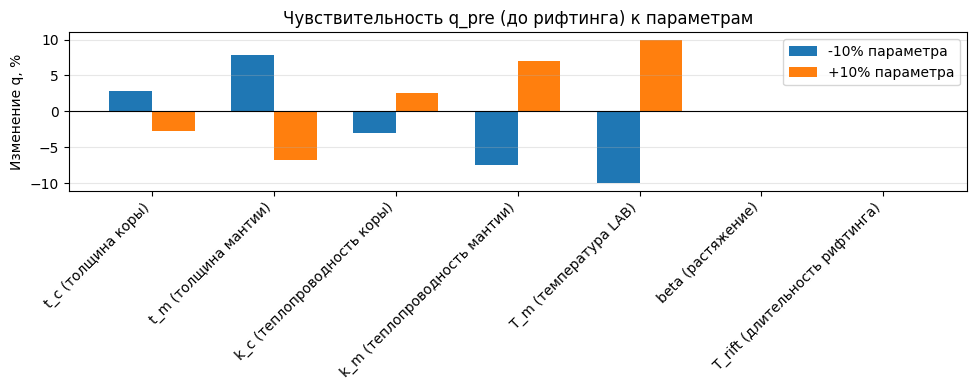

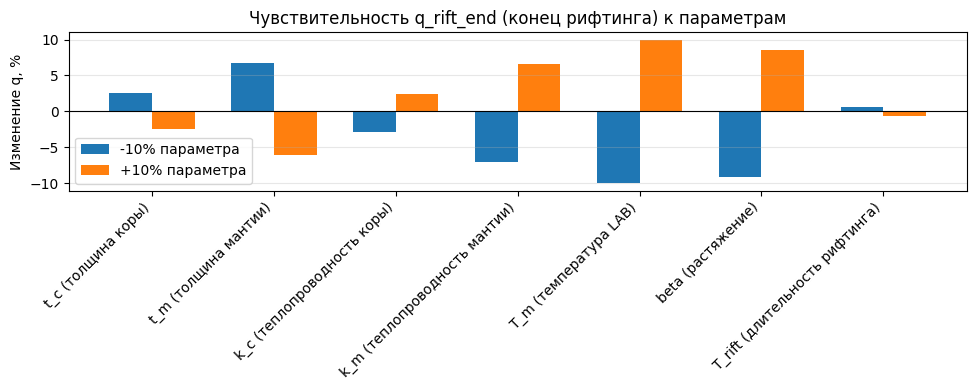

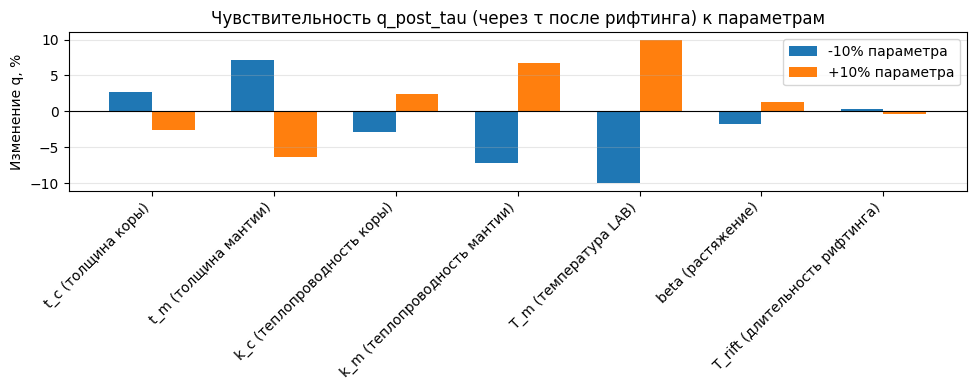

In [106]:
# ---------- Визуализация ----------

param_labels = [p[0] for p in params]
x = np.arange(len(param_labels))
width = 0.35  # ширина столбика

# Функция для одного графика
def plot_phase(phase_key, title):
    fig, ax = plt.subplots(figsize=(10, 4))

    plus_vals  = [results_plus[name][phase_key]  for name in param_labels]
    minus_vals = [results_minus[name][phase_key] for name in param_labels]

    ax.bar(x - width/2, minus_vals, width, label='-10% параметра')
    ax.bar(x + width/2, plus_vals,  width, label='+10% параметра')

    ax.set_xticks(x)
    ax.set_xticklabels(param_labels, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_ylabel('Изменение q, %')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_phase("q_pre", "Чувствительность q_pre (до рифтинга) к параметрам")

plot_phase("q_rift_end", "Чувствительность q_rift_end (конец рифтинга) к параметрам")

plot_phase("q_post_tau", "Чувствительность q_post_tau (через τ после рифтинга) к параметрам")


Исходная литосфера: 125.0 км
Новая литосфера:    41.7 км
q до рифтинга (модель) ~ 20.80 mW/m^2
q сразу после рифтинга (модель) ~ 62.40 mW/m^2
Коэфф. схемы r = 0.153 (для FTCS нужно r <= 0.5)
RMS несовпадение (post-rift) модель vs Petromod: 12.60 mW/m^2


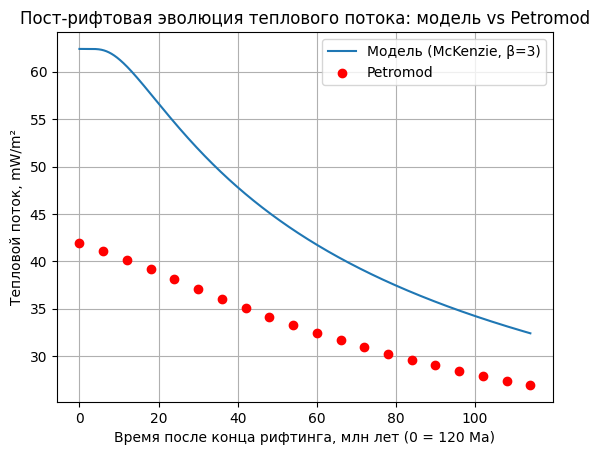

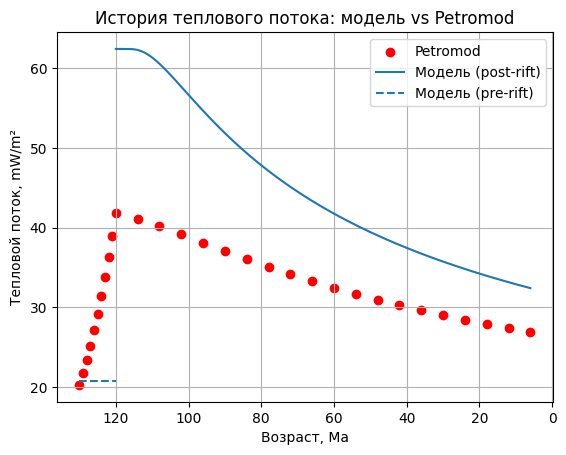

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1. Параметры из Petromod
# ------------------------------
k = 2.0          # теплопроводность, W/m/K
Ts = 0.0          # температура поверхности, °C
Tm = 1300.0       # температура астеносферы, °C

hc0 = 30e3        # толщина коры до рифтинга, м
hm0 = 95e3        # толщина мантии литосферы, м
zl0 = hc0 + hm0   # общая литосфера, м

beta = 3.0        # фактор растяжения (один на обе литологии)
hc_new = hc0 / beta
hm_new = hm0 / beta
zl_new = hc_new + hm_new

rho = 3300.0      # плотность, кг/м3
Cp = 1250.0       # теплоёмкость, Дж/кг/К
kappa = k / (rho * Cp)

print(f"Исходная литосфера: {zl0/1000:.1f} км")
print(f"Новая литосфера:    {zl_new/1000:.1f} км")

# ------------------------------
# 2. Данные Petromod
# ------------------------------
ages_pet = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102,96,90,84,78,72,66,60,54,48,42,36,30,24,18,12,6
], dtype=float)

q_pet = np.array([
    20.28,21.79,23.43,25.2,27.11,29.17,31.39,33.76,36.3,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,
    31.67,30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)  # mW/m2

# Пост-рифтовые точки (<=120 Ma)
ages_post_pet = ages_pet[ages_pet <= 120]
q_post_pet = q_pet[ages_pet <= 120]
t_post_pet = 120.0 - ages_post_pet   # Myr после конца рифтинга

# ------------------------------
# 3. Сетка по глубине
# ------------------------------
Zmax = 200e3      # глубина модели, м
nz = 201
z = np.linspace(0, Zmax, nz)
dz = z[1] - z[0]

# ------------------------------
# 4. Геотерм до рифтинга (стационарный)
# ------------------------------
T0 = np.zeros_like(z)
for i, zi in enumerate(z):
    if zi <= zl0:
        T0[i] = Ts + (Tm - Ts) * (zi / zl0)
    else:
        T0[i] = Tm

# ------------------------------
# 5. Профиль сразу после рифтинга (t = 0+), мгновенное растяжение
# ------------------------------
T_init = np.zeros_like(z)

for i, z_new in enumerate(z):
    if z_new <= hc_new:
        # кора
        z_old = z_new * beta
    elif z_new <= zl_new:
        # мантия литосферы
        z_old = hc0 + (z_new - hc_new) * beta
    else:
        # астеносфера
        z_old = zl0 + (z_new - zl_new)

    if z_old >= Zmax:
        T_init[i] = T0[-1]
    else:
        j = int(z_old // dz)
        if j >= nz - 1:
            T_init[i] = T0[-1]
        else:
            w = (z_old - z[j]) / dz
            T_init[i] = (1 - w) * T0[j] + w * T0[j + 1]

# ------------------------------
# 6. Функция теплового потока (вверх)
# ------------------------------
def surface_heatflow(T_profile):
    dTdz = (T_profile[1] - Ts) / dz  # ось z вниз
    q = k * dTdz                     # трактуем как поток вверх
    return q

q_before = surface_heatflow(T0)
q_0plus = surface_heatflow(T_init)

print(f"q до рифтинга (модель) ~ {q_before*1e3:.2f} mW/m^2")
print(f"q сразу после рифтинга (модель) ~ {q_0plus*1e3:.2f} mW/m^2")

# ------------------------------
# 7. Временная эволюция после рифтинга
# ------------------------------
t_max_Myr = t_post_pet.max()   # максимум времени после рифтинга (у тебя это 120-6 = 114 Myr)
dt_Myr = 0.01                   # шаг по времени
dt_s = dt_Myr * 1e6 * 365.25 * 24 * 3600

nsteps = int(t_max_Myr / dt_Myr)
times_model = np.linspace(0.0, t_max_Myr, nsteps+1)

r = kappa * dt_s / dz**2
print(f"Коэфф. схемы r = {r:.3f} (для FTCS нужно r <= 0.5)")

T = T_init.copy()
q_model = np.zeros_like(times_model)
q_model[0] = q_0plus

for n in range(1, nsteps+1):
    T_new = T.copy()
    T_new[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])
    T_new[0] = Ts
    T_new[-1] = Tm
    T = T_new
    q_model[n] = surface_heatflow(T)

# ------------------------------
# 8. Сравнение модель vs Petromod
# ------------------------------
q_model_at_pet = np.interp(t_post_pet, times_model, q_model) * 1e3  # mW/m2
q_pet_post = q_post_pet

rms_misfit = np.sqrt(np.mean((q_model_at_pet - q_pet_post)**2))
print(f"RMS несовпадение (post-rift) модель vs Petromod: {rms_misfit:.2f} mW/m^2")

# ------------------------------
# 9. Графики
# ------------------------------

# 9.1. Время после конца рифтинга (0 = 120 Ma)
plt.figure()
plt.plot(times_model, q_model * 1e3, label="Модель (McKenzie, β=3)")
plt.scatter(t_post_pet, q_pet_post, color='r', label="Petromod", zorder=3)
plt.xlabel("Время после конца рифтинга, млн лет (0 = 120 Ma)")
plt.ylabel("Тепловой поток, mW/m²")
plt.title("Пост-рифтовая эволюция теплового потока: модель vs Petromod")
plt.legend()
plt.grid(True)
plt.show()

# 9.2. То же, но в координатах возраста (Ma)
ages_model = 120.0 - times_model  # возраст, Ma, для пост-рифтовой части
plt.figure()
plt.scatter(ages_pet, q_pet, color='r', label="Petromod")
mask_post = ages_model <= 120.0
plt.plot(ages_model[mask_post], (q_model*1e3)[mask_post], label="Модель (post-rift)")
plt.hlines(q_before*1e3, xmin=130, xmax=120, linestyles='dashed', label="Модель (pre-rift)")
plt.gca().invert_xaxis()
plt.xlabel("Возраст, Ma")
plt.ylabel("Тепловой поток, mW/m²")
plt.title("История теплового потока: модель vs Petromod")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
import numpy as np

Myr_to_s = 1e6 * 365.25 * 24 * 3600.0

# -----------------------------
# 1. До рифтинга: двухслойный стационар
# -----------------------------
def initial_geotherm_two_layer(z, hc0, hm0, Ts, Tm, k_c, k_m):
    """
    Строим T(z) и поток q до рифтинга для двух слоёв:
      0..hc0     : кора с k_c
      hc0..hc0+hm0 : мантия с k_m
    Нет радиогенного тепла.
    """
    zl0 = hc0 + hm0

    # общий стационарный поток (W/m2)
    q = (Tm - Ts) / (hc0 / k_c + hm0 / k_m)

    T0 = np.zeros_like(z, dtype=float)
    for i, zi in enumerate(z):
        if zi <= hc0:
            T0[i] = Ts + q * zi / k_c
        elif zi <= zl0:
            T0[i] = Ts + q * hc0 / k_c + q * (zi - hc0) / k_m
        else:
            T0[i] = Tm
    return T0, q

# -----------------------------
# 2. Мгновенное растяжение с beta_c, beta_m
# -----------------------------
def stretch_temperature_beta_two_layer(T0, z, hc0, hm0, beta_c, beta_m):
    """
    Мгновенный рифтинг: отдельные β для коры и мантии.
    hc0, hm0 : исходные толщины коры/мантии (м)
    beta_c, beta_m : факторы растяжения
    Возвращает:
      T_rift(z)
      h_c_new, h_m_new (м)
    """
    zl0 = hc0 + hm0
    h_c_new = hc0 / beta_c
    h_m_new = hm0 / beta_m
    zl_new = h_c_new + h_m_new

    nz = len(z)
    dz = z[1] - z[0]
    T_rift = np.zeros_like(T0)

    for i, z_new in enumerate(z):
        if z_new <= h_c_new:
            # кора
            z_old = z_new * beta_c
        elif z_new <= zl_new:
            # мантия
            z_old = hc0 + (z_new - h_c_new) * beta_m
        else:
            # астеносфера
            z_old = zl0 + (z_new - zl_new)

        # интерполяция по T0
        if z_old <= 0:
            T_rift[i] = T0[0]
        elif z_old >= z[-1]:
            T_rift[i] = T0[-1]
        else:
            j = int(z_old // dz)
            if j >= nz - 1:
                T_rift[i] = T0[-1]
            else:
                w = (z_old - z[j]) / dz
                T_rift[i] = (1 - w) * T0[j] + w * T0[j + 1]

    return T_rift, h_c_new, h_m_new

# -----------------------------
# 3. Пострифтовое охлаждение: Backward Euler с переменным k, rhoCp
# -----------------------------
def solve_conduction_two_layer(
    T_init, z,
    h_c, h_m,
    k_c, k_m,
    rhoCp_c, rhoCp_m,
    Ts, Tm,
    t_Myr, n_steps
):
    """
    rhoCp(z) dT/dt = d/dz( k(z) dT/dz )
    Два слоя: кора и мантия, разные k и rhoCp.
    Граничные условия: T(0,t)=Ts, T(z_max,t)=Tm.
    Неявная схема по времени (Backward Euler).
    """
    z = np.asarray(z)
    nz = len(z)
    dz = z[1] - z[0]

    zl = h_c + h_m

    # профили k(z), rhoCp(z)
    k_z = np.zeros_like(z)
    rhoCp_z = np.zeros_like(z)

    for i, zi in enumerate(z):
        if zi <= h_c:
            k_z[i] = k_c
            rhoCp_z[i] = rhoCp_c
        elif zi <= zl:
            k_z[i] = k_m
            rhoCp_z[i] = rhoCp_m
        else:
            # ниже литосферы: оставим k_m, rhoCp_m и T ~ Tm
            k_z[i] = k_m
            rhoCp_z[i] = rhoCp_m

    # предварительно вычисляем k на полуинтервалах (гармоническое среднее)
    k_half = np.zeros(nz - 1)
    k_half[:] = 2.0 * k_z[:-1] * k_z[1:] / (k_z[:-1] + k_z[1:] + 1e-30)

    # время
    t_total_s = t_Myr * Myr_to_s
    dt_s = t_total_s / n_steps

    T = T_init.copy()

    # размер внутренней области (узлы 1..nz-2)
    N = nz - 2
    lower = np.zeros(N)
    diag  = np.zeros(N)
    upper = np.zeros(N)
    rhs   = np.zeros(N)

    # буферы для Томаса
    c_prime = np.zeros(N)
    d_prime = np.zeros(N)

    for step in range(n_steps):
        # собираем матрицу и правую часть
        for i in range(1, nz - 1):
            idx = i - 1

            k_imh = k_half[i - 1]   # k_{i-1/2}
            k_iph = k_half[i]       # k_{i+1/2}

            alpha = k_imh / dz**2
            beta  = k_iph / dz**2

            rhoCp_i = rhoCp_z[i]

            a_i = -alpha
            b_i = rhoCp_i / dt_s + alpha + beta
            c_i = -beta

            lower[idx] = a_i
            diag[idx]  = b_i
            upper[idx] = c_i

            rhs[idx] = rhoCp_i / dt_s * T[i]  # A(z)=0

        # добавляем граничные условия (Dirichlet)
        i = 1
        idx = 0
        k_imh = k_half[i - 1]
        alpha = k_imh / dz**2
        rhs[idx] += alpha * Ts

        i = nz - 2
        idx = N - 1
        k_iph = k_half[i]
        beta = k_iph / dz**2
        rhs[idx] += beta * Tm

        # прямой ход Томаса
        c_prime[0] = upper[0] / diag[0]
        d_prime[0] = rhs[0] / diag[0]
        for i in range(1, N):
            denom = diag[i] - lower[i] * c_prime[i - 1]
            c_prime[i] = upper[i] / denom if i < N - 1 else 0.0
            d_prime[i] = (rhs[i] - lower[i] * d_prime[i - 1]) / denom

        # обратный ход
        T_new = T.copy()
        T_new[0]  = Ts
        T_new[-1] = Tm
        T_new[nz - 2] = d_prime[-1]
        for i in range(N - 2, -1, -1):
            T_new[i + 1] = d_prime[i] - c_prime[i] * T_new[i + 2]

        T = T_new

    return T

# -----------------------------
# 4. Тепловой поток на поверхности (вверх)
# -----------------------------
def surface_heatflow_up(T_profile, z, k_surface):
    """
    Тепловой поток ВВЕРХ, как в Petromod (положительный при нормальном геотерме).
    Ось z вниз.
    q_up = k * dT/dz, где dT/dz > 0 при росте T с глубиной.
    """
    dz = z[1] - z[0]
    dTdz = (T_profile[1] - T_profile[0]) / dz
    q_up = k_surface * dTdz  # W/m2
    return q_up

# -----------------------------
# 5. Пример использования
# -----------------------------
if __name__ == "__main__":
    # Граничные температуры
    Ts = 20.0
    Tm = 1300.0

    # Толщины до рифтинга
    hc0 = 30e3   # кора, м
    hm0 = 95e3   # мантия литосферы, м

    # Теплопроводность
    k_c = 2.0    # кора, W/mK
    k_m = 2.0    # мантия, W/mK  (в твоём примере они равны, но можно задавать по-разному)

    # rho*Cp (объёмная теплоёмкость), для примера одинаковая
    rhoCp_c = 3300 * 1250   # кора
    rhoCp_m = 3300 * 1250   # мантия

    # Сетка по глубине
    Zmax = 200e3
    nz = 401
    z = np.linspace(0, Zmax, nz)

    # 1) ДО РИФТИНГА
    T0, q0 = initial_geotherm_two_layer(z, hc0, hm0, Ts, Tm, k_c, k_m)
    q0_up = surface_heatflow_up(T0, z, k_c) * 1e3  # mW/m2

    # 2) МОМЕНТ РИФТИНГА (мгновенный β-ріфтинг)
    beta_c = 1.2   # фактор растяжения коры
    beta_m = 1.2   # фактор растяжения мантии (в твоём примере они одинаковые)
    T_rift, h_c_new, h_m_new = stretch_temperature_beta_two_layer(T0, z, hc0, hm0, beta_c, beta_m)
    q_rift_up = surface_heatflow_up(T_rift, z, k_c) * 1e3  # mW/m2

    # 3) МОМЕНТ ОКОНЧАНИЯ (например, через 120 Myr после рифтинга)
    T_final = solve_conduction_two_layer(
        T_rift, z,
        h_c_new, h_m_new,
        k_c, k_m,
        rhoCp_c, rhoCp_m,
        Ts, Tm,
        t_Myr=120.0,
        n_steps=300
    )
    q_final_up = surface_heatflow_up(T_final, z, k_c) * 1e3  # mW/m2

    print(f"До рифтинга:         q = {q0_up:.2f} mW/m²")
    print(f"Сразу после рифтинга: q = {q_rift_up:.2f} mW/m²")
    print(f"Через 120 Myr:        q = {q_final_up:.2f} mW/m²")
    print(f"Новая кора = {h_c_new/1000:.1f} км, новая мантия = {h_m_new/1000:.1f} км")


До рифтинга:         q = 20.48 mW/m²
Сразу после рифтинга: q = 24.58 mW/m²
Через 120 Myr:        q = 22.47 mW/m²
Новая кора = 25.0 км, новая мантия = 79.2 км


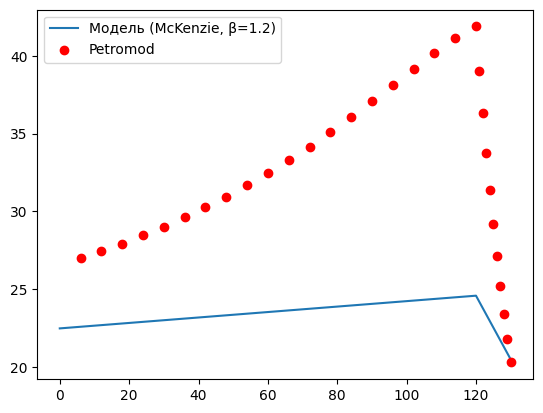

In [63]:
ages_pet = np.array([
    130,129,128,127,126,125,124,123,122,121,120,
    114,108,102,96,90,84,78,72,66,60,54,48,42,36,30,24,18,12,6
], dtype=float)

q_pet = np.array([
    20.28,21.79,23.43,25.2,27.11,29.17,31.39,33.76,36.3,39.01,41.89,
    41.13,40.19,39.17,38.12,37.08,36.06,35.09,34.16,33.28,32.45,
    31.67,30.94,30.26,29.62,29.02,28.45,27.93,27.43,26.97
], dtype=float)  # mW/m2

plt.plot([130, 120, 0], np.abs([q0_up, q_rift_up, q_final_up]), label="Модель (McKenzie, β=1.2)")
plt.scatter(ages_pet, q_pet, color='r', label="Petromod", zorder=3)
plt.legend()

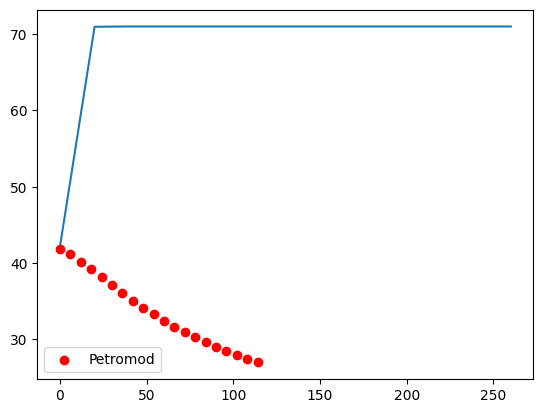

/tmp/ipython-input-3715330800.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_num = np.trapz(T_anom * S, z)
/tmp/ipython-input-3715330800.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_den = np.trapz(S * S, z)


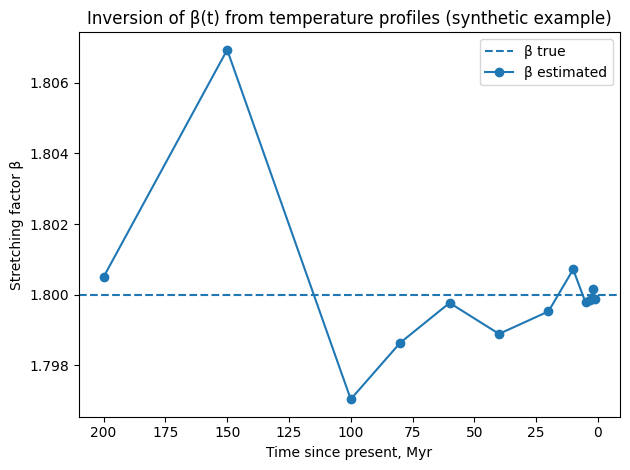

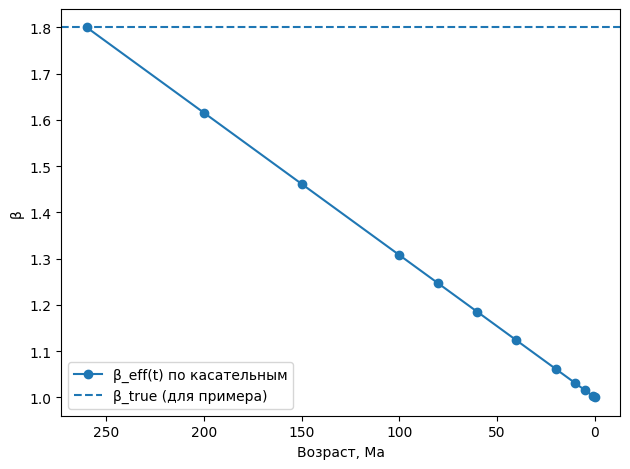

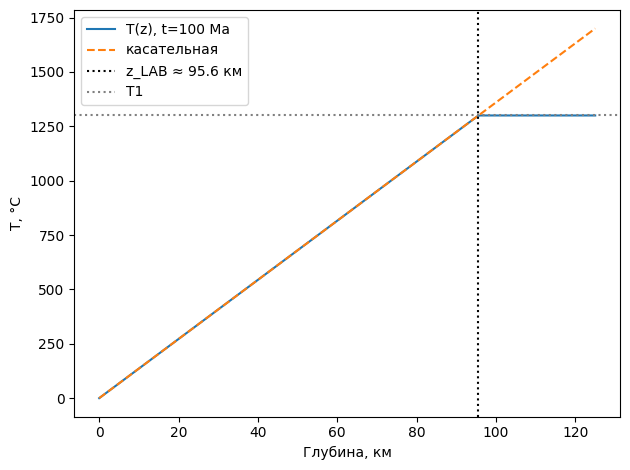

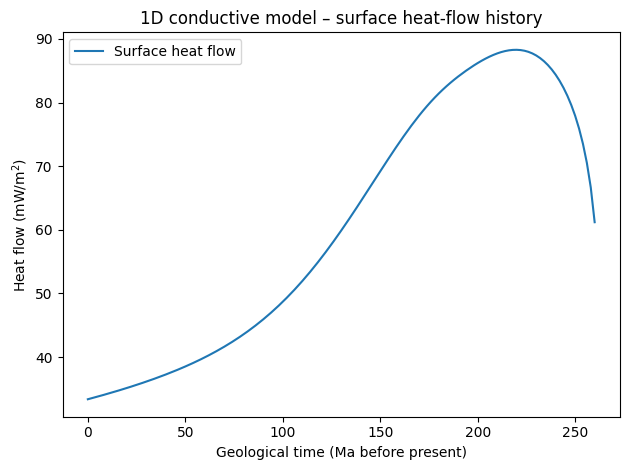

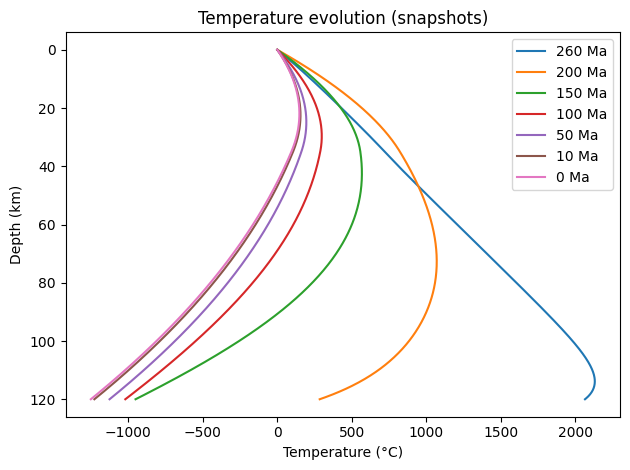

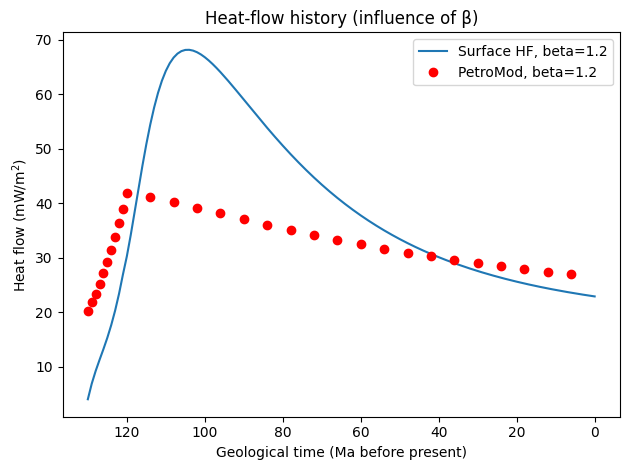

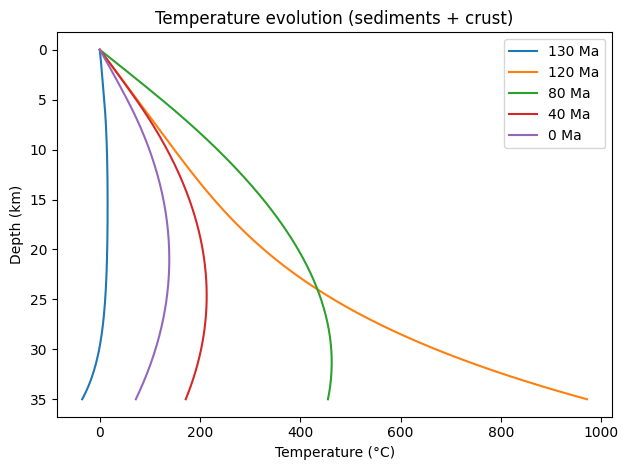

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================
# 1D BASIN MODEL + McKENZIE LITHOSPHERE (β_c, β_m)
# =============================================

class Basin1D_McKenzie:
    """
    1D тепловая модель осадочного бассейна с базальным потоком
    из литосферы по Маккензи (через beta_mantle) + влияние beta_crust.

    Параметры:
    - beta_crust, beta_mantle: коэффициенты растяжения коры и мантии
    - k_sed, k_crust, k_mantle: теплопроводности осадков, коры и мантии (Вт/м/К)
    - a_lith0: исходная мощность литосферы (м)
    - L_crust0: исходная мощность коры (до рифтинга, м)
    - H_sed: мощность осадков (м) внутри L_crust (0–H_sed–Литосфера)
    - T1: температура астеносферы (°C)
    - kappa: температуропроводность литосферы (м²/с)
    - t_rift_start, t_rift_end: время начала/конца растяжения (Ма до настоящего)
    """

    def __init__(
        self,
        beta_crust=1.2,
        beta_mantle=1.2,
        k_sed=2.0,
        k_crust=2.5,
        k_mantle=2.5,
        a_lith0=125e3,
        L_crust0=35e3,
        H_sed=5e3,
        nz=150,
        rho=2700.0,
        cp=1000.0,
        H_sed_heat=0.5e-6,   # Вт/м³, осадки
        H_crust_heat=1.5e-6, # Вт/м³, кора
        T_surf=0.0,
        T1=1300.0,
        kappa=1e-6,
        t_rift_start=130.0,
        t_rift_end=120.0
    ):
        # параметры рифтинга
        self.beta_crust = beta_crust
        self.beta_mantle = beta_mantle

        # мощности до рифтинга
        self.a_lith0 = a_lith0       # исходная толщина литосферы
        self.L_crust0 = L_crust0     # исходная толщина коры (до β_crust)
        self.H_sed = H_sed           # мощность осадков (часть коры)

        # физические свойства
        self.k_sed = k_sed
        self.k_crust = k_crust
        self.k_mantle = k_mantle
        self.rho = rho
        self.cp = cp
        self.H_sed_heat = H_sed_heat
        self.H_crust_heat = H_crust_heat
        self.T_surf = T_surf
        self.T1 = T1
        self.kappa = kappa

        # времена рифтинга
        self.t_rift_start = t_rift_start
        self.t_rift_end = t_rift_end

        # сетка по толщине коры + осадков (колонка до Мохо)
        self.nz = nz
        self.z = np.linspace(0.0, L_crust0, nz)
        self.dz = self.z[1] - self.z[0]

        # массивы теплопроводности и радиогенного тепла (осадки + кора)
        self.k = np.zeros(nz)
        self.H = np.zeros(nz)

        # заполняем: 0–H_sed — осадки, H_sed–L_crust0 — кора
        sed_mask = self.z <= H_sed
        crust_mask = self.z > H_sed

        self.k[sed_mask] = k_sed
        self.k[crust_mask] = k_crust

        self.H[sed_mask] = H_sed_heat
        self.H[crust_mask] = H_crust_heat

    # --------- Маккензи: коэффициент Фурье b_n(β) (безразмерный) ----------
    @staticmethod
    def mckenzie_b_n(beta, n):
        """
        Коэффициент Фурье b_n из McKenzie (1980), безразмерный:
        b_n = (2/pi) * (-1)^{n+1} * (beta / n) * sin(n*pi/beta)
        """
        return (2.0 / np.pi) * beta * ((-1) ** (n + 1)) * np.sin(n * np.pi / beta) / n

    # --------- q_b по Маккензи: пост-рифтинговое охлаждение ----------
    def _qb_series(self, tau_s, n_terms=100):
        """
        Вспомогательная функция: q_b(τ) по Маккензи (пост-рифтинг),
        τ — время с конца растяжения в секундах.
        Возвращает q_b в Вт/м² на верхней границе литосферы (Мохо).
        """
        a = self.a_lith0           # толщина литосферы ДО рифтинга
        kappa = self.kappa
        beta = self.beta_mantle
        T1 = self.T1

        # S = sum_{n=1..∞} n * b_n * exp(-n^2 π^2 κ τ / a^2)
        S = 0.0
        for n in range(1, n_terms + 1):
            b_n = self.mckenzie_b_n(beta, n)
            decay = np.exp(-(n ** 2) * np.pi ** 2 * kappa * tau_s / a ** 2)
            S += n * b_n * decay

        # ∂T/∂z при z=0 (верх литосферы / основание коры), по формуле из McKenzie
        # T(z,t) = T1[(1 - z/a) + Σ b_n exp(-...) sin(nπz/a)]
        # => dT/dz|0 = T1[-1/a + (π/a) Σ n b_n exp(-...)]
        dTdz_0 = T1 * (-1.0 / a + (np.pi / a) * S)

        # тепловой поток вверх из литосферы (на Мохо): q = -k * dT/dz
        q_b = -self.k_mantle * dTdz_0  # Вт/м²
        return q_b

    def basal_heatflow_mckenzie(self, t_Myr, n_terms=100):
        """
        Базальный тепловой поток на Мохо q_b(t) [mW/m²],
        с учётом β_mantle по модели Маккензи.

        Логика:
        - t >= t_rift_start: до рифтинга → стационарный q0
        - t_rift_start > t > t_rift_end: фаза растяжения → линейный переход
        - t <= t_rift_end: пост-рифтинговое охлаждение по Маккензи
        """
        # фон: до рифтинга литосфера в стационарном состоянии
        q0_W = self.k_mantle * self.T1 / self.a_lith0  # Вт/м²

        Myr_to_s = 1e6 * 365.25 * 24 * 3600.0

        # 1) до рифтинга
        if t_Myr >= self.t_rift_start:
            return q0_W * 1e3  # mW/m²

        # 2) во время рифтинга — простая линейная интерполяция между q0 и q(τ=0)
        if self.t_rift_start > t_Myr > self.t_rift_end:
            q_rift_W = self._qb_series(0.0, n_terms)  # момент сразу после рифта
            frac = (self.t_rift_start - t_Myr) / (self.t_rift_start - self.t_rift_end)
            q_b_W = q0_W + frac * (q_rift_W - q0_W)
            return q_b_W * 1e3

        # 3) пост-рифтинг: классическое охлаждение Маккензи
        tau_s = (self.t_rift_end - t_Myr) * Myr_to_s  # τ >= 0
        q_b_W = self._qb_series(tau_s, n_terms)
        return q_b_W * 1e3  # mW/m²

    # --------- Численное решение в осадочной колонке ----------
    def run(self, t_start_Myr=130.0, t_end_Myr=0.0, dt_Myr=1.0,
            T_init_geotherm=0.0):
        """
        Решение уравнения теплопроводности в осадки+кора (0–L_crust0)
        с базальным потоком q_b(t) из литосферной модели Маккензи.

        Возвращает:
            times_Myr : массив времён (от старого к новому)
            T_hist    : массив температур [nt, nz]
            q_surf    : поверхностный тепловой поток [mW/m²]
            q_basal   : базальный поток (на Мохо) [mW/m²]
        """
        times_Myr = np.arange(t_start_Myr, t_end_Myr - 1e-9, -dt_Myr)
        nt = len(times_Myr)

        Myr_to_s = 1e6 * 365.25 * 24 * 3600.0
        dt_s = dt_Myr * Myr_to_s

        # начальная T: простой линейный градиент
        T = self.T_surf + (T_init_geotherm / 1000.0) * self.z

        T_hist = np.zeros((nt, self.nz))
        q_surf = np.zeros(nt)
        q_basal = np.zeros(nt)

        nz = self.nz
        dz = self.dz
        rho_cp = self.rho * self.cp

        for it, t_Myr in enumerate(times_Myr):
            # базальный поток с учётом β_mantle
            q_b_mW = self.basal_heatflow_mckenzie(t_Myr)
            q_basal[it] = q_b_mW
            q_b = q_b_mW * 1e-3  # Вт/м²

            # эффективное радиогенное тепло с учётом beta_crust:
            # после рифтинга кора тоньше → меньше радиогенного тепла
            if t_Myr <= self.t_rift_end:
                H_factor = 1.0 / self.beta_crust
            else:
                H_factor = 1.0
            H_profile = self.H * H_factor

            # матрица A и вектор b (неявная схема)
            A = np.zeros((nz, nz))
            b = np.zeros(nz)

            # верх: T(0) = T_surf
            A[0, 0] = 1.0
            b[0] = self.T_surf

            # внутренние узлы
            for i in range(1, nz - 1):
                kmh = 0.5 * (self.k[i - 1] + self.k[i])
                kph = 0.5 * (self.k[i] + self.k[i + 1])

                coef_m = kmh / dz ** 2
                coef_p = kph / dz ** 2
                coef_0 = -(coef_m + coef_p)

                A[i, i - 1] = -dt_s / rho_cp * coef_m
                A[i, i]     = 1.0 - dt_s / rho_cp * coef_0
                A[i, i + 1] = -dt_s / rho_cp * coef_p

                b[i] = T[i] + dt_s * H_profile[i] / rho_cp

            # низ: -k * dT/dz = q_b  ->  T_N-1 - T_N-2 = -dz * q_b / k_last
            k_last = self.k[-1]
            A[-1, -2] = -1.0
            A[-1, -1] = 1.0
            b[-1] = -dz * q_b / k_last

            # решаем СЛАУ
            T_new = np.linalg.solve(A, b)
            T = T_new
            T_hist[it, :] = T

            # поверхностный тепловой поток
            dTdz_surface = (T[1] - T[0]) / dz
            q_surf[it] = -self.k[0] * dTdz_surface * 1e3  # mW/m²

        self.times_Myr = times_Myr
        self.T_hist = T_hist
        self.q_surf = q_surf
        self.q_basal = q_basal
        return times_Myr, T_hist, q_surf, q_basal


# -----------------------
# Твои экспериментальные точки
# -----------------------
time_points_m1 = np.array([
    6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96,
    102, 108, 114, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130
])
heat_flow_m1 = np.array([
    26.97, 27.43, 27.93, 28.45, 29.02, 29.62, 30.26, 30.94, 31.67, 32.45,
    33.28, 34.16, 35.09, 36.06, 37.08, 38.12, 39.17, 40.19, 41.13, 41.89,
    39.01, 36.3, 33.76, 31.39, 29.17, 27.11, 25.2, 23.43, 21.79, 20.28
])


# ============================
# Демонстрационный запуск
# ============================
if __name__ == "__main__":
    # Пример: сильный рифтинг beta=6 в коре и мантии
    model = Basin1D_McKenzie(
        beta_crust=1.2,
        beta_mantle=1.2,
        k_sed=2.0,
        k_crust=2.0,
        k_mantle=2.0,
        a_lith0=125e3,
        L_crust0=35e3,
        H_sed=5e3,
        nz=150,
        T_surf=0.0,
        T1=1330.0,
        kappa=1e-6,
        t_rift_start=130.0,
        t_rift_end=120.0
    )

    times_Myr, T_hist, q_surf, q_basal = model.run(
        t_start_Myr=130.0,
        t_end_Myr=0.0,
        dt_Myr=1.0,
        T_init_geotherm=0.0
    )

    # ---- 1) Поверхностный тепловой поток + твои данные ----
    plt.figure()
    plt.plot(times_Myr, np.abs(q_surf), label=f"Surface HF, beta={model.beta_mantle}")
    plt.plot(time_points_m1, heat_flow_m1, "o", color="red", label="PetroMod, beta=1.2")
    plt.gca().invert_xaxis()
    plt.xlabel("Geological time (Ma before present)")
    plt.ylabel("Heat flow (mW/m$^2$)")
    plt.title("Heat-flow history (influence of β)")
    plt.legend()
    plt.tight_layout()

    # ---- 2) Температурные профили во времени ----
    plt.figure()
    depth_km = model.z / 1000.0
    for t_plot in [130, 120, 80, 40, 0]:
        idx = np.argmin(np.abs(times_Myr - t_plot))
        plt.plot(T_hist[idx, :], depth_km, label=f"{t_plot:.0f} Ma")
    plt.gca().invert_yaxis()
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Depth (km)")
    plt.title("Temperature evolution (sediments + crust)")
    plt.legend()
    plt.tight_layout()

    plt.show()


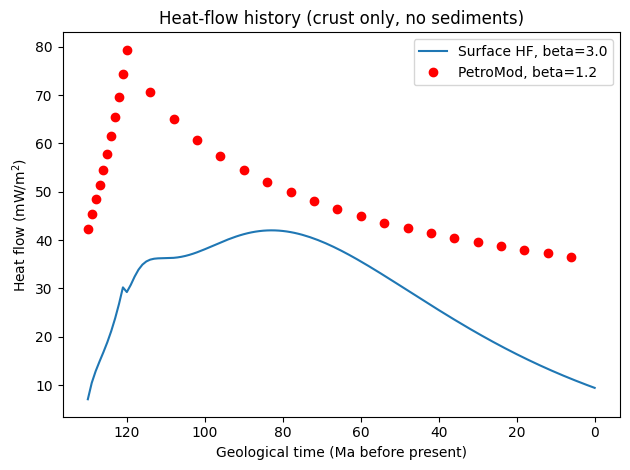

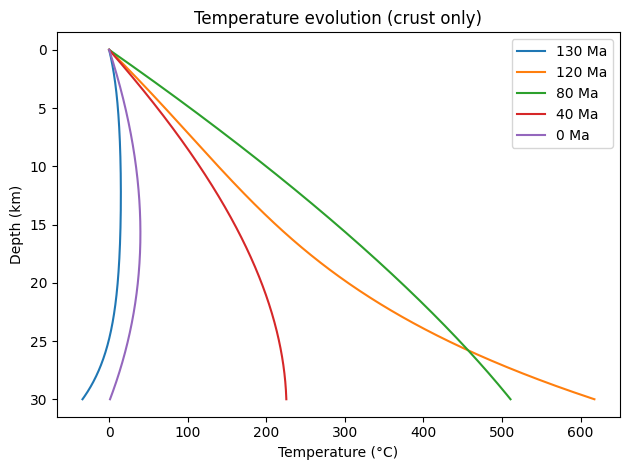

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================
# 1D BASIN MODEL + McKENZIE LITHOSPHERE (β_c, β_m), БЕЗ ОСАДКОВ
# =============================================

class Basin1D_McKenzie:
    """
    1D тепловая модель: только кора (0–L_crust0) + литосферная мантия ниже.
    Базальный поток на Мохо считается по Маккензи (через beta_mantle),
    beta_crust влияет на радиогенное тепло (тонкая кора после рифта).
    """

    def __init__(
        self,
        beta_crust=1.2,
        beta_mantle=1.2,
        k_crust=2.5,         # теплопроводность коры (Вт/м/К)
        k_mantle=2.5,        # теплопроводность литосферной мантии (Вт/м/К)
        a_lith0=125e3,       # исходная мощность литосферы (м)
        L_crust0=35e3,       # исходная мощность коры (м)
        nz=150,
        rho=2700.0,
        cp=1000.0,
        H_crust_heat=1.5e-6, # Вт/м³, радиогенное тепло в коре
        T_surf=0.0,
        T1=1300.0,
        kappa=1e-6,
        t_rift_start=130.0,
        t_rift_end=120.0
    ):
        # параметры рифтинга
        self.beta_crust = beta_crust
        self.beta_mantle = beta_mantle

        # мощности до рифтинга
        self.a_lith0 = a_lith0       # толщина литосферы до рифта
        self.L_crust0 = L_crust0     # толщина коры до рифта

        # физические свойства
        self.k_crust = k_crust
        self.k_mantle = k_mantle
        self.rho = rho
        self.cp = cp
        self.H_crust_heat = H_crust_heat
        self.T_surf = T_surf
        self.T1 = T1
        self.kappa = kappa

        # времена рифтинга
        self.t_rift_start = t_rift_start
        self.t_rift_end = t_rift_end

        # сетка по толщине коры (0–L_crust0)
        self.nz = nz
        self.z = np.linspace(0.0, L_crust0, nz)
        self.dz = self.z[1] - self.z[0]

        # массивы теплопроводности и радиогенного тепла (вся колонка — кора)
        self.k = np.full(nz, k_crust)
        self.H = np.full(nz, H_crust_heat)

    # --------- Маккензи: коэффициент Фурье b_n(β) ----------
    @staticmethod
    def mckenzie_b_n(beta, n):
        """
        Коэффициент Фурье b_n из McKenzie (1980), безразмерный:
        b_n = (2/pi) * (-1)^{n+1} * (beta / n) * sin(n*pi/beta)
        """
        return (2.0 / np.pi) * beta * ((-1) ** (n + 1)) * np.sin(n * np.pi / beta) / n

    # --------- q_b по Маккензи: пост-рифтинговое охлаждение ----------
    def _qb_series(self, tau_s, n_terms=100):
        """
        Вспомогательная функция: q_b(τ) по Маккензи (пост-рифтинг),
        τ — время с конца растяжения в секундах.
        Возвращает q_b в Вт/м² на верхней границе литосферы (Мохо).
        """
        a = self.a_lith0           # толщина литосферы до рифтинга
        kappa = self.kappa
        beta = self.beta_mantle
        T1 = self.T1

        # S = sum_{n=1..∞} n * b_n * exp(-n^2 π^2 κ τ / a^2)
        S = 0.0
        for n in range(1, n_terms + 1):
            b_n = self.mckenzie_b_n(beta, n)
            decay = np.exp(-(n ** 2) * np.pi ** 2 * kappa * tau_s / a ** 2)
            S += n * b_n * decay

        # dT/dz|0 = T1[-1/a + (π/a) Σ n b_n exp(-...)]
        dTdz_0 = T1 * (-1.0 / a + (np.pi / a) * S)

        # тепловой поток вверх на Мохо: q = -k_mantle * dT/dz
        q_b = -self.k_mantle * dTdz_0  # Вт/м²
        return q_b

    def basal_heatflow_mckenzie(self, t_Myr, n_terms=100):
        """
        Базальный тепловой поток на Мохо q_b(t) [mW/m²]
        с учётом beta_mantle по модели Маккензи.

        - t >= t_rift_start: до рифтинга → стационарный q0
        - t_rift_start > t > t_rift_end: фаза растяжения → линейный переход
        - t <= t_rift_end: пост-рифтинговое охлаждение
        """
        # фон: до рифтинга литосфера в стац. состоянии
        q0_W = self.k_mantle * self.T1 / self.a_lith0  # Вт/м²

        Myr_to_s = 1e6 * 365.25 * 24 * 3600.0

        # 1) до рифтинга
        if t_Myr >= self.t_rift_start:
            return q0_W * 1e3  # mW/m²

        # 2) во время рифтинга — линейный переход q0 → q_rift
        if self.t_rift_start > t_Myr > self.t_rift_end:
            q_rift_W = self._qb_series(0.0, n_terms)  # сразу после рифта
            frac = (self.t_rift_start - t_Myr) / (self.t_rift_start - self.t_rift_end)
            q_b_W = q0_W + frac * (q_rift_W - q0_W)
            return q_b_W * 1e3

        # 3) пост-рифтинг
        tau_s = (self.t_rift_end - t_Myr) * Myr_to_s  # τ >= 0
        q_b_W = self._qb_series(tau_s, n_terms)
        return q_b_W * 1e3  # mW/m²

    # --------- Численное решение в коре ----------
    def run(self, t_start_Myr=130.0, t_end_Myr=0.0, dt_Myr=1.0,
            T_init_geotherm=0.0):
        """
        Решение уравнения теплопроводности в коре (0–L_crust0)
        с базальным потоком q_b(t) из литосферной модели Маккензи.
        """
        times_Myr = np.arange(t_start_Myr, t_end_Myr - 1e-9, -dt_Myr)
        nt = len(times_Myr)

        Myr_to_s = 1e6 * 365.25 * 24 * 3600.0
        dt_s = dt_Myr * Myr_to_s

        # начальная T: линейный градиент
        T = self.T_surf + (T_init_geotherm / 1000.0) * self.z

        T_hist = np.zeros((nt, self.nz))
        q_surf = np.zeros(nt)
        q_basal = np.zeros(nt)

        nz = self.nz
        dz = self.dz
        rho_cp = self.rho * self.cp

        for it, t_Myr in enumerate(times_Myr):
            # базальный поток с учётом beta_mantle
            q_b_mW = self.basal_heatflow_mckenzie(t_Myr)
            q_basal[it] = q_b_mW
            q_b = q_b_mW * 1e-3  # Вт/м²

            # радиогенное тепло: после рифта уменьшаем в 1/beta_crust
            if t_Myr <= self.t_rift_end:
                H_factor = 1.0 / self.beta_crust
            else:
                H_factor = 1.0
            H_profile = self.H * H_factor

            # матрица A и вектор b (implicit Euler)
            A = np.zeros((nz, nz))
            b = np.zeros(nz)

            # верх: T(0) = T_surf
            A[0, 0] = 1.0
            b[0] = self.T_surf

            # внутренние узлы
            for i in range(1, nz - 1):
                kmh = 0.5 * (self.k[i - 1] + self.k[i])
                kph = 0.5 * (self.k[i] + self.k[i + 1])

                coef_m = kmh / dz ** 2
                coef_p = kph / dz ** 2
                coef_0 = -(coef_m + coef_p)

                A[i, i - 1] = -dt_s / rho_cp * coef_m
                A[i, i]     = 1.0 - dt_s / rho_cp * coef_0
                A[i, i + 1] = -dt_s / rho_cp * coef_p

                b[i] = T[i] + dt_s * H_profile[i] / rho_cp

            # низ: -k * dT/dz = q_b  →  T_N-1 - T_N-2 = -dz*q_b/k_last
            k_last = self.k[-1]
            A[-1, -2] = -1.0
            A[-1, -1] = 1.0
            b[-1] = -dz * q_b / k_last

            # решаем СЛАУ
            T_new = np.linalg.solve(A, b)
            T = T_new
            T_hist[it, :] = T

            # поверхностный тепловой поток
            dTdz_surface = (T[1] - T[0]) / dz
            q_surf[it] = -self.k[0] * dTdz_surface * 1e3  # mW/m²

        self.times_Myr = times_Myr
        self.T_hist = T_hist
        self.q_surf = q_surf
        self.q_basal = q_basal
        return times_Myr, T_hist, q_surf, q_basal


# -----------------------
# Твои экспериментальные точки
# -----------------------
# time_points_m1 = np.array([
#     6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96,
#     102, 108, 114, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130
# ])
# heat_flow_m1 = np.array([
#     26.97, 27.43, 27.93, 28.45, 29.02, 29.62, 30.26, 30.94, 31.67, 32.45,
#     33.28, 34.16, 35.09, 36.06, 37.08, 38.12, 39.17, 40.19, 41.13, 41.89,
#     39.01, 36.3, 33.76, 31.39, 29.17, 27.11, 25.2, 23.43, 21.79, 20.28
# ])

time_points_m1 = np.array([130, 129, 128, 127, 126, 125, 124, 123, 122, 121,
                      120, 114, 108, 102, 96, 90, 84, 78, 72, 66,
                      60, 54, 48, 42, 36, 30, 24, 18, 12, 6])

heat_flow_m1 = np.array([42.2, 45.49, 48.49, 51.46, 54.54, 57.85, 61.45, 65.39, 69.69, 74.36,
                    79.36, 70.68, 65.02, 60.74, 57.29, 54.41, 51.97, 49.86, 48.01, 46.38,
                    44.93, 43.63, 42.45, 41.38, 40.41, 39.52, 38.7, 37.94, 37.24, 36.59])


# ============================
# Демонстрационный запуск
# ============================
if __name__ == "__main__":
    model = Basin1D_McKenzie(
        beta_crust=3.0,
        beta_mantle=3.0,
        k_crust=1.97,
        k_mantle=1.97,
        a_lith0=125e3,
        L_crust0=30e3,
        nz=500,
        T_surf=0.0,
        T1=1330.0,
        kappa=1e-6,
        t_rift_start=130.0,
        t_rift_end=120.0
    )

    times_Myr, T_hist, q_surf, q_basal = model.run(
        t_start_Myr=130.0,
        t_end_Myr=0.0,
        dt_Myr=1.0,
        T_init_geotherm=0.0
    )

    # ---- 1) Поверхностный тепловой поток + твои данные ----
    plt.figure()
    plt.plot(times_Myr, np.abs(q_surf), label=f"Surface HF, beta={model.beta_mantle}")
    plt.plot(time_points_m1, heat_flow_m1, "o", color="red", label="PetroMod, beta=1.2")
    plt.gca().invert_xaxis()
    plt.xlabel("Geological time (Ma before present)")
    plt.ylabel("Heat flow (mW/m$^2$)")
    plt.title("Heat-flow history (crust only, no sediments)")
    plt.legend()
    plt.tight_layout()

    # ---- 2) Температурные профили во времени ----
    plt.figure()
    depth_km = model.z / 1000.0
    for t_plot in [130, 120, 80, 40, 0]:
        idx = np.argmin(np.abs(times_Myr - t_plot))
        plt.plot(T_hist[idx, :], depth_km, label=f"{t_plot:.0f} Ma")
    plt.gca().invert_yaxis()
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Depth (km)")
    plt.title("Temperature evolution (crust only)")
    plt.legend()
    plt.tight_layout()

    plt.show()


Истинный β: 2.50
Оцененный из температурного профиля: 2.50
Оцененный из теплового потока: 2.50
Поверхностный тепловой поток: -37.1 mW/m²


UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

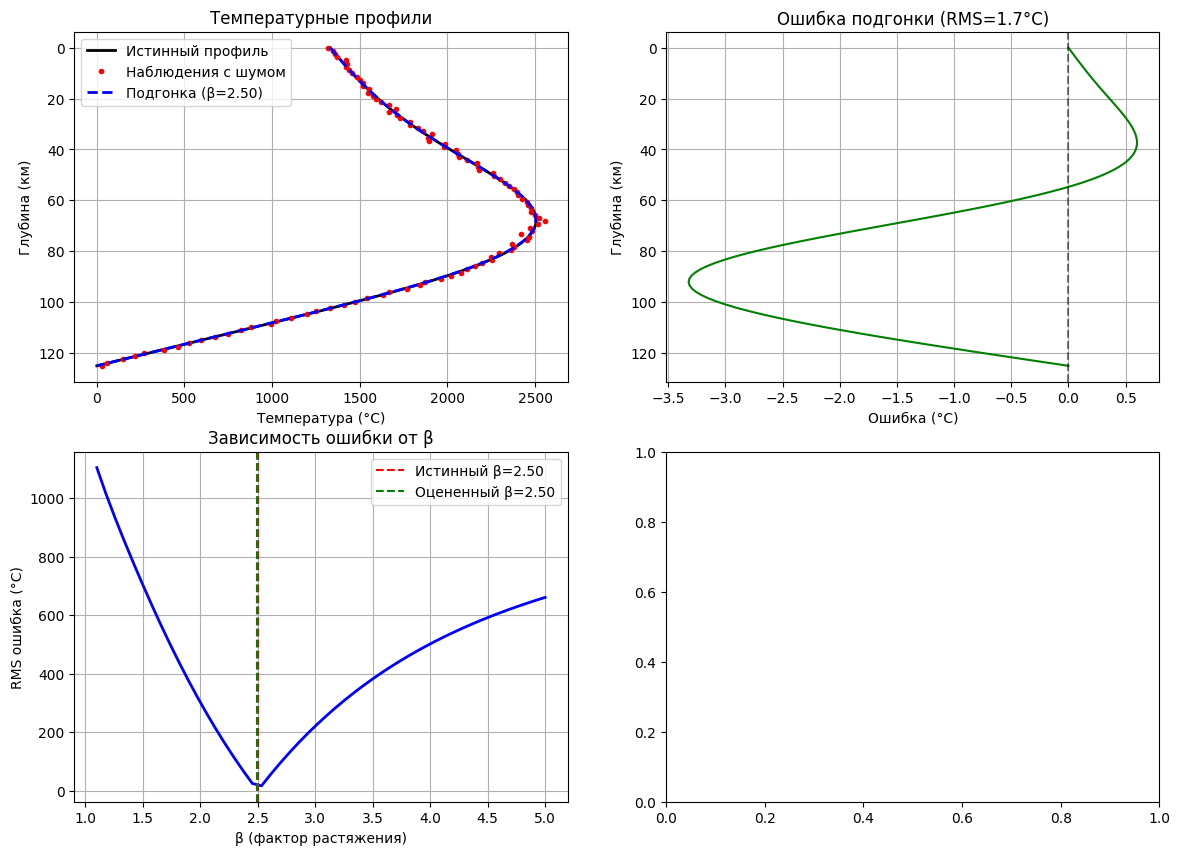

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.optimize import minimize

# Physical parameters from Table 1 (McKenzie 1978)
a_km = 125               # Lithosphere thickness (km)
a = a_km * 1e3           # Convert to meters
kappa = 8.04e-7          # Thermal diffusivity (m²/s)
T1 = 1330                # Asthenospheric temperature (°C)
alpha = 3.28e-5          # Thermal expansion coefficient (°C⁻¹)
rho_0 = 3.33e3           # Lithosphere density at 0°C (kg/m³)
rho_c = 2.8e3            # Crust density at 0°C (kg/m³)
rho_w = 1.03e3           # Water density (kg/m³)
t_c_km = 35              # Initial crustal thickness (km)
t_c = t_c_km * 1e3       # Convert to meters

seconds_per_Myr = 1e6 * 365.25 * 24 * 3600  # s/Myr

# ============================================
# ФУНКЦИИ ДЛЯ ОПРЕДЕЛЕНИЯ β ИЗ ТЕМПЕРАТУРНОГО ПРОФИЛЯ
# ============================================

def initial_temp_profile(z, a, beta, T1):
    """Уравнение 20: Начальный профиль температуры после растяжения"""
    condition = (z <= a * (1 - 1/beta))
    return np.where(condition, T1, T1 * beta * (1 - z/a))

def temperature_cooling_phase(z, t_Myr, At_Myr, a, kappa, b_n, n_max, T1):
    """Уравнение 18: Температура в фазе остывания"""
    if t_Myr < At_Myr:
        raise ValueError("t must be ≥ At")
    
    t_seconds = (t_Myr - At_Myr) * seconds_per_Myr
    T_ss = T1 * (1 - z/a)
    temp_sum = np.zeros_like(z)
    
    for n in range(1, n_max + 1):
        lambda_n = n * np.pi / a
        term = b_n[n-1] * np.sin(lambda_n * z) * np.exp(-lambda_n**2 * kappa * t_seconds)
        temp_sum += term
    
    return T_ss + temp_sum * T1

def compute_bn_analytical(n_max, beta):
    """Аналитические коэффициенты b_n"""
    b_n = []
    for n in range(1, n_max + 1):
        bn = (2 / np.pi) * ((-1)**(n+1)) * (beta / n) * np.sin(n * np.pi / beta)
        b_n.append(bn)
    return np.array(b_n)

def estimate_beta_from_temperature(z_obs, T_obs, time_after_stretching, a, kappa, T1):
    """
    Определение β из наблюдаемого температурного профиля
    
    Parameters:
    -----------
    z_obs : array
        Наблюдаемые глубины (м)
    T_obs : array
        Наблюдаемые температуры (°C)
    time_after_stretching : float
        Время после растяжения (Myr)
    a : float
        Толщина литосферы (м)
    kappa : float
        Тепловая диффузия
    T1 : float
        Температура астеносферы
        
    Returns:
    --------
    beta_est : float
        Оцененный фактор растяжения
    T_fit : array
        Подобранный температурный профиль
    """
    
    def objective(beta, n_max=50):
        """Целевая функция для минимизации"""
        b_n = compute_bn_analytical(n_max, beta)
        T_model = temperature_cooling_phase(z_obs, time_after_stretching, 0, a, kappa, b_n, n_max, T1)
        # Взвешенная ошибка (больший вес для больших глубин)
        weights = 1.0 + 0.5 * (z_obs / a)**2
        mse = np.mean(weights * (T_model - T_obs)**2)
        return mse
    
    # Начальное предположение и ограничения
    beta_guess = 2.0
    bounds = [(1.01, 10.0)]  # β должен быть > 1
    
    # Оптимизация
    result = minimize(objective, beta_guess, bounds=bounds, method='L-BFGS-B')
    beta_est = result.x[0]
    
    # Расчет финального профиля
    b_n_final = compute_bn_analytical(50, beta_est)
    T_fit = temperature_cooling_phase(z_obs, time_after_stretching, 0, a, kappa, b_n_final, 50, T1)
    
    return beta_est, T_fit

def beta_from_surface_heat_flow(q_surface, time_after_stretching, a, kappa, T1, k_rock=3.0):
    """
    Определение β из поверхностного теплового потока
    
    Parameters:
    -----------
    q_surface : float
        Поверхностный тепловой поток (mW/m²)
    time_after_stretching : float
        Время после растяжения (Myr)
    a : float
        Толщина литосферы (м)
    kappa : float
        Тепловая диффузия
    T1 : float
        Температура астеносферы
    k_rock : float
        Теплопроводность пород (W/(m·K))
        
    Returns:
    --------
    beta_est : float
        Оцененный фактор растяжения
    """
    
    # Тепловой поток для ненарушенной литосферы
    q0 = k_rock * T1 / a  # W/m²
    q0_mw = q0 * 1000     # mW/m²
    
    def objective(beta, n_max=50):
        """Рассчитываем тепловой поток для заданного β"""
        b_n = compute_bn_analytical(n_max, beta)
        
        # Расчет температурного градиента у поверхности
        z_small = np.array([0.0, 10.0])  # Малая глубина для градиента
        T = temperature_cooling_phase(z_small, time_after_stretching, 0, a, kappa, b_n, n_max, T1)
        dT_dz = (T[1] - T[0]) / (z_small[1] - z_small[0])
        
        # Тепловой поток
        q_calc = -k_rock * dT_dz * 1000  # mW/m²
        
        return (q_calc - q_surface)**2
    
    # Оптимизация
    beta_guess = 2.0
    bounds = [(1.01, 10.0)]
    
    result = minimize(objective, beta_guess, bounds=bounds, method='L-BFGS-B')
    return result.x[0]

# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================

# Генерация тестовых данных (симулируем наблюдения)
z_obs = np.linspace(0, a, 100)
true_beta = 2.5
time_after = 10.0  # Myr после растяжения

# Расчет температурного профиля для "истинного" β
b_n_true = compute_bn_analytical(50, true_beta)
T_obs = temperature_cooling_phase(z_obs, time_after, 0, a, kappa, b_n_true, 50, T1)

# Добавляем шум к наблюдениям (симулируем реальные данные)
noise = np.random.normal(0, 20, len(z_obs))  # Шум 20°C
T_obs_noisy = T_obs + noise

# 1. Определение β из температурного профиля
beta_est_temp, T_fit = estimate_beta_from_temperature(z_obs, T_obs_noisy, time_after, a, kappa, T1)
print(f"Истинный β: {true_beta:.2f}")
print(f"Оцененный из температурного профиля: {beta_est_temp:.2f}")

# 2. Определение β из теплового потока
# Расчет теплового потока для истинного профиля
k_rock = 3.0  # W/(m·K)
dT_dz_surface = np.gradient(T_obs, z_obs)[0]  # Градиент у поверхности
q_surface_true = -k_rock * dT_dz_surface * 1000  # mW/m²

beta_est_heatflow = beta_from_surface_heat_flow(q_surface_true, time_after, a, kappa, T1, k_rock)
print(f"Оцененный из теплового потока: {beta_est_heatflow:.2f}")
print(f"Поверхностный тепловой поток: {q_surface_true:.1f} mW/m²")

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Температурные профили
ax1 = axes[0, 0]
ax1.plot(T_obs, z_obs/1000, 'k-', linewidth=2, label='Истинный профиль')
ax1.plot(T_obs_noisy, z_obs/1000, 'ro', markersize=3, label='Наблюдения с шумом')
ax1.plot(T_fit, z_obs/1000, 'b--', linewidth=2, label=f'Подгонка (β={beta_est_temp:.2f})')
ax1.set_xlabel('Температура (°C)')
ax1.set_ylabel('Глубина (км)')
ax1.set_title('Температурные профили')
ax1.legend()
ax1.grid(True)
ax1.invert_yaxis()

# 2. Ошибка подгонки
ax2 = axes[0, 1]
error = T_fit - T_obs
ax2.plot(error, z_obs/1000, 'g-', linewidth=1.5)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Ошибка (°C)')
ax2.set_ylabel('Глубина (км)')
ax2.set_title(f'Ошибка подгонки (RMS={np.sqrt(np.mean(error**2)):.1f}°C)')
ax2.grid(True)
ax2.invert_yaxis()

# 3. Зависимость ошибки от β
ax3 = axes[1, 0]
beta_test = np.linspace(1.1, 5.0, 50)
errors = []
for beta_val in beta_test:
    b_n_test = compute_bn_analytical(50, beta_val)
    T_test = temperature_cooling_phase(z_obs, time_after, 0, a, kappa, b_n_test, 50, T1)
    error_val = np.sqrt(np.mean((T_test - T_obs)**2))
    errors.append(error_val)

ax3.plot(beta_test, errors, 'b-', linewidth=2)
ax3.axvline(x=true_beta, color='r', linestyle='--', label=f'Истинный β={true_beta:.2f}')
ax3.axvline(x=beta_est_temp, color='g', linestyle='--', label=f'Оцененный β={beta_est_temp:.2f}')
ax3.set_xlabel('β (фактор растяжения)')
ax3.set_ylabel('RMS ошибка (°C)')
ax3.set_title('Зависимость ошибки от β')
ax3.legend()
ax3.grid(True)

# 4. Тепловой поток для разных β
ax4 = axes[1, 1]
times = np.linspace(0, 100, 100)  # 0-100 Myr

for beta_plot in [1.0, 1.5, 2.0, 2.5, 3.0]:
    q_values = []
    for t in times:
        b_n = compute_bn_analytical(50, beta_plot)
        T = temperature_cooling_phase(np.array([0, 10]), t, 0, a, kappa, b_n, 50, T1)
        dT_dz = (T[1] - T[0]) / 10
        q = -k_rock * dT_dz * 1000
        q_values.append(q)
    
    ax4.plot(times, q_values, label=f'β={beta_plot}', linewidth=2)

ax4.axhline(y=q_surface_true, color='k', linestyle='--', label=f'Измеренный: {q_surface_true:.1f} mW/m²')
ax4.set_xlabel('Время после растяжения (Myr)')
ax4.set_ylabel('Тепловой поток (mW/m²)')
ax4.set_title('Эволюция теплового потока')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# ФУНКЦИЯ ДЛЯ ИНВЕРСИИ ПО РАЗНЫМ ГЛУБИНАМ
# ============================================

def estimate_beta_depth_varying(z_obs, T_obs, time_after, a, kappa, T1, depth_windows=None):
    """
    Оценка β для разных глубинных окон
    (позволяет оценить вариации растяжения с глубиной)
    
    Parameters:
    -----------
    depth_windows : list of tuples
        [(z1_min, z1_max), (z2_min, z2_max), ...]
        Если None, используется три равных интервала
    """
    
    if depth_windows is None:
        # Разбиваем на три равных интервала
        z_max = z_obs[-1]
        depth_windows = [
            (0, z_max/3),
            (z_max/3, 2*z_max/3),
            (2*z_max/3, z_max)
        ]
    
    beta_results = []
    T_fit_all = np.zeros_like(z_obs)
    
    fig, axes = plt.subplots(1, len(depth_windows), figsize=(15, 5))
    if len(depth_windows) == 1:
        axes = [axes]
    
    for idx, (z_min, z_max) in enumerate(depth_windows):
        # Выбираем данные в текущем окон
        mask = (z_obs >= z_min) & (z_obs <= z_max)
        z_window = z_obs[mask]
        T_window = T_obs[mask]
        
        # Оцениваем β для этого окна
        beta_est, T_fit_window = estimate_beta_from_temperature(
            z_window, T_window, time_after, a, kappa, T1
        )
        beta_results.append((z_min, z_max, beta_est))
        
        # Сохраняем подобранный профиль
        T_fit_all[mask] = T_fit_window
        
        # Визуализация
        ax = axes[idx]
        ax.plot(T_window, z_window/1000, 'ro', markersize=3, label='Наблюдения')
        ax.plot(T_fit_window, z_window/1000, 'b-', linewidth=2, 
                label=f'Подгонка\nβ={beta_est:.2f}')
        ax.set_xlabel('Температура (°C)')
        ax.set_ylabel('Глубина (км)')
        ax.set_title(f'Глубинный интервал: {z_min/1000:.0f}-{z_max/1000:.0f} км')
        ax.legend()
        ax.grid(True)
        ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return beta_results, T_fit_all

# Пример использования глубинной инверсии
print("\n" + "="*50)
print("ГЛУБИННАЯ ИНВЕРСИЯ:")
print("="*50)

beta_by_depth, T_fit_depth = estimate_beta_depth_varying(
    z_obs, T_obs_noisy, time_after, a, kappa, T1
)

for z_min, z_max, beta_val in beta_by_depth:
    print(f"Глубина {z_min/1000:.0f}-{z_max/1000:.0f} км: β = {beta_val:.2f}")

РАСЧЕТЫ ДЛЯ ПРИМЕРА ИЗ КНИГИ

РАСЧЕТЫ ДЛЯ ВАШИХ ПАРАМЕТРОВ
Характерное время релаксации: 5.4e+08 лет
[  0  50 100 150 200 250]


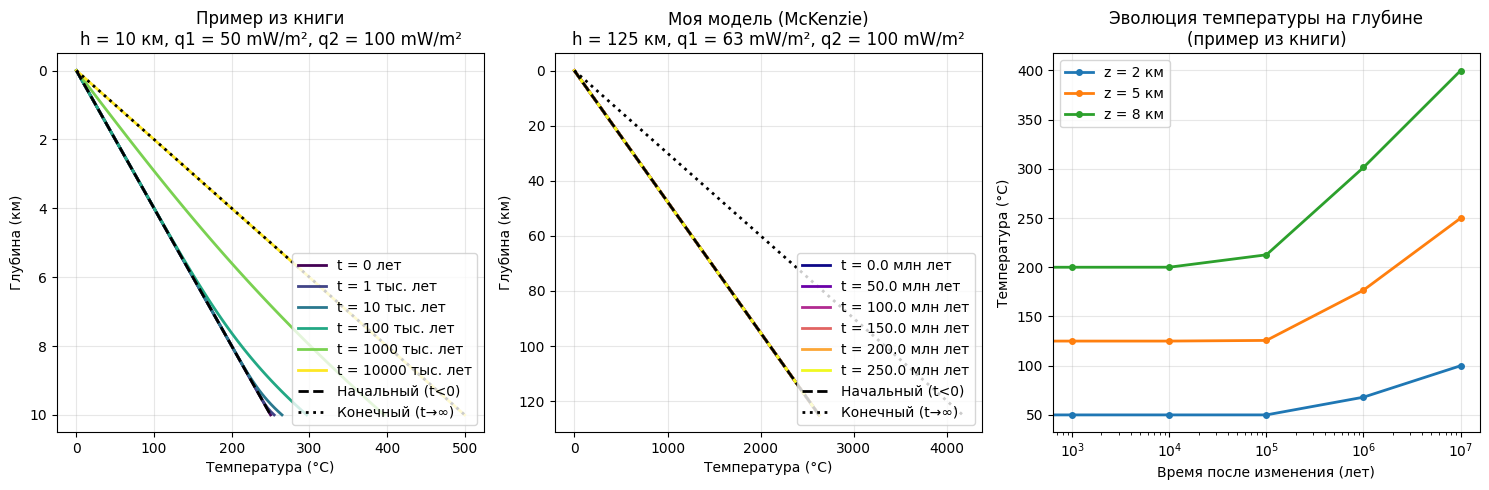

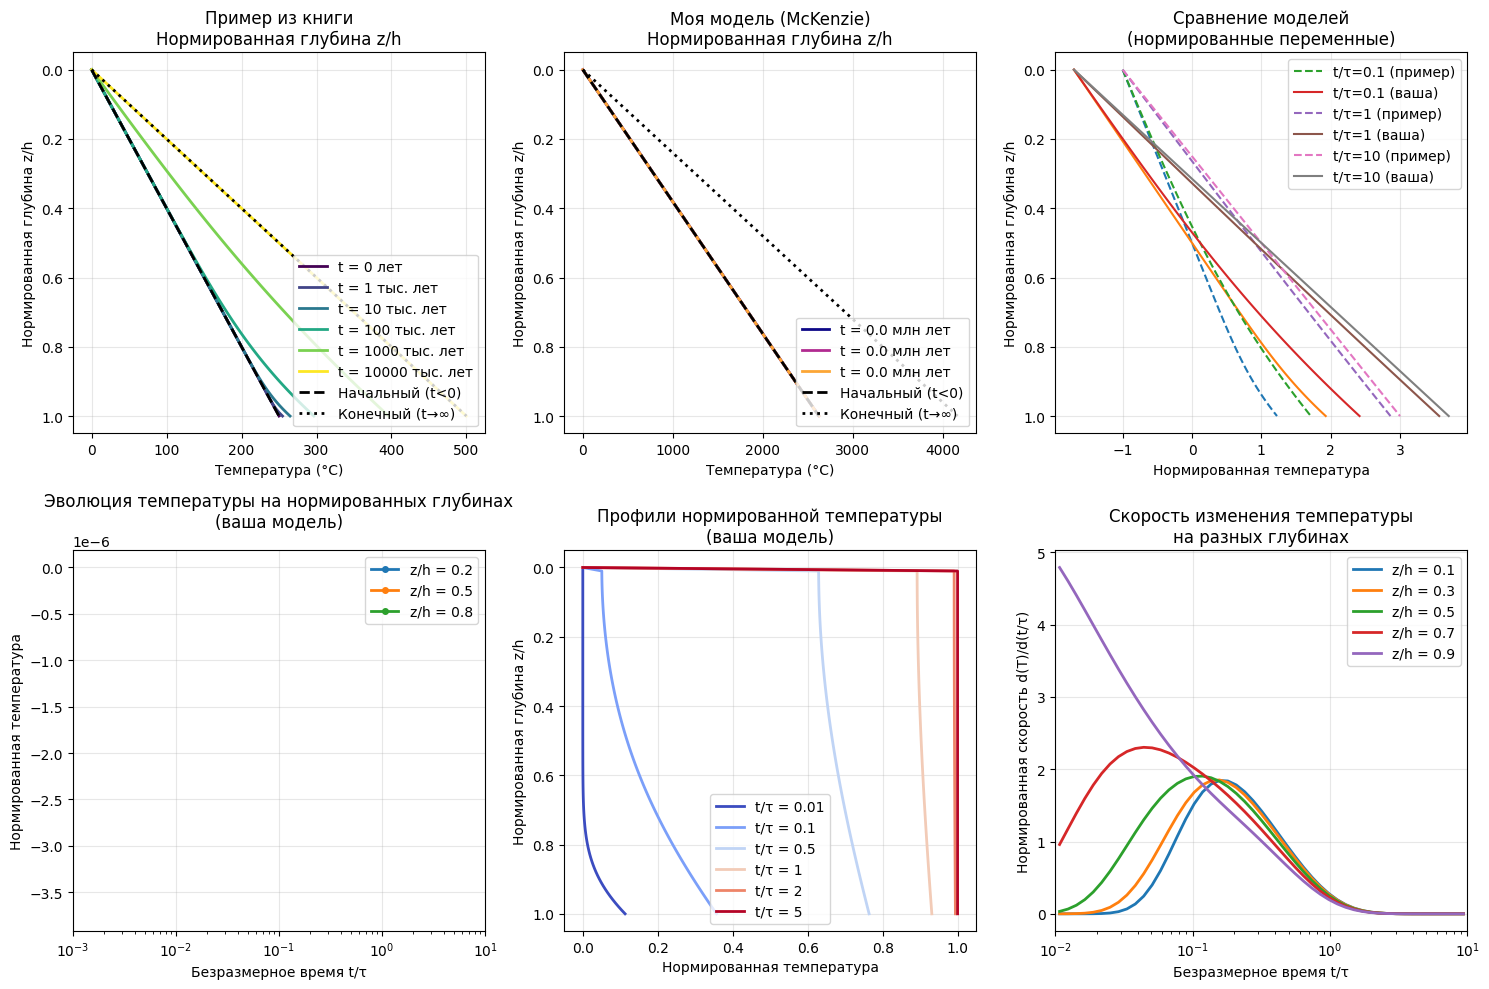


АНАЛИЗ НОРМИРОВАННЫХ ГРАФИКОВ

1. Преимущества нормирования глубины z/h:
   - Позволяет сравнивать системы с разными масштабами
   - Универсальный масштаб: z/h = 0 (поверхность), z/h = 1 (астеносфера)
   - Упрощает анализ физических процессов

2. Ключевые наблюдения:
   - Характерное время релаксации τ = h²/κ:
     * Пример: τ = 3.68 млн лет
     * Ваша модель: τ = 544.94 млн лет
   - Отношение времен релаксации: 148.0 раз

3. Геологическая интерпретация нормированных графиков:
   - z/h = 0.5 соответствует середине литосферы (~62.5 км для вашей модели)
   - z/h = 0.8 соответствует глубине ~100 км (зона перехода)
   - Безразмерное время t/τ показывает стадию релаксации:
     * t/τ < 0.1: начальная стадия
     * 0.1 < t/τ < 1: активная релаксация
     * t/τ > 1: приближение к равновесию

4. Практическое применение:
   - Нормированные графики позволяют применять результаты
     к литосфере разной толщины
   - Можно оценить время достижения заданной температуры
     на любой глубине в лит

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# ============================================
# ПАРАМЕТРЫ ИЗ ПРИМЕРА (Рис. F.9)
# ============================================

# Параметры из примера
params_example = {
    'h': 10e3,          # Толщина слоя, м (10 км)
    'Ts': 0,            # Температура на поверхности, °C
    'q1': 50e-3,        # Начальный тепловой поток, W/m² (50 mW/m²)
    'q2': 100e-3,       # Новый тепловой поток после t=0, W/m² (100 mW/m²)
    'lambda_val': 2.0,  # Теплопроводность, W/(m·K)
    'rho': 2700,        # Плотность, kg/m³
    'c': 860,           # Удельная теплоемкость, J/(kg·K)
    'name': 'Пример из книги'
}

# ============================================
# ВАШИ ПАРАМЕТРЫ (на основе McKenzie 1978)
# ============================================

params_yours = {
    'h': 125e3,         # Толщина литосферы, м (125 км) - глубина астеносферы
    'Ts': 0,            # Температура на поверхности, °C
    'q1': 63e-3,        # Начальный тепловой поток, W/m² (63 mW/m²) - типичный континентальный
    'q2': 100e-3,       # Новый тепловой поток (например, после растяжения), W/m²
    'lambda_val': 3.0,  # Теплопроводность, W/(m·K) - среднее для пород
    'rho': 3300,        # Плотность, kg/m³
    'c': 1000,          # Удельная теплоемкость, J/(kg·K)
    'name': 'Моя модель (McKenzie)'
}

# ============================================
# ФУНКЦИИ МОДЕЛИ
# ============================================

def calculate_temperature_profile(z, t, params, n_terms=500):
    """
    Расчет температурного профиля по формуле (F.15)
    
    Parameters:
    -----------
    z : array or float
        Глубина (м)
    t : float
        Время после изменения теплового потока (секунды)
    params : dict
        Параметры модели
    n_terms : int
        Количество членов ряда
    
    Returns:
    --------
    T : array or float
        Температура (°C)
    """
    
    # Извлекаем параметры
    h = params['h']
    Ts = params['Ts']
    q1 = params['q1']
    q2 = params['q2']
    lambda_val = params['lambda_val']
    rho = params['rho']
    c = params['c']
    
    # Температуропроводность
    kappa = lambda_val / (rho * c)
    
    # Стационарная часть (новое стационарное состояние)
    T_steady = Ts + (q2 / lambda_val) * z
    
    if t <= 0:
        # Для t <= 0 возвращаем начальный стационарный профиль
        return Ts + (q1 / lambda_val) * z
    
    # Переходная часть (ряд Фурье)
    T_transient = 0.0
    
    # Суммируем ряд от -n_terms до n_terms
    for n in range(-n_terms, n_terms + 1):
        mu_n = (n + 0.5) * np.pi / h
        
        # Коэффициент ряда
        coeff = ((-1)**n) / (h * mu_n**2)
        
        # Пространственная зависимость
        spatial = np.sin(mu_n * z)
        
        # Временная зависимость
        temporal = np.exp(-mu_n**2 * kappa * t)
        
        T_transient += coeff * spatial * temporal
    
    # Полная температура
    T = T_steady + ((q1 - q2) / lambda_val) * T_transient
    
    return T

# ============================================
# РАСЧЕТЫ ДЛЯ ПРИМЕРА ИЗ КНИГИ
# ============================================

print("="*60)
print("РАСЧЕТЫ ДЛЯ ПРИМЕРА ИЗ КНИГИ")
print("="*60)

# Времена для расчета (в секундах)
year_to_sec = 3.154e7
times_years = np.array([0, 1000, 10000, 100000, 1e6, 10e6])  # лет
times_seconds = times_years * year_to_sec

# Глубинная сетка
z_example = np.linspace(0, params_example['h'], 100)

# Расчет профилей для разных времен
profiles_example = []
for t_sec in times_seconds:
    T_profile = calculate_temperature_profile(z_example, t_sec, params_example)
    profiles_example.append(T_profile)

# ============================================
# РАСЧЕТЫ ДЛЯ ВАШИХ ПАРАМЕТРОВ
# ============================================

print("\n" + "="*60)
print("РАСЧЕТЫ ДЛЯ ВАШИХ ПАРАМЕТРОВ")
print("="*60)

# Времена для вашей модели (более длинные из-за большей толщины)
kappa_yours = params_yours['lambda_val'] / (params_yours['rho'] * params_yours['c'])
characteristic_time = (params_yours['h']**2) / kappa_yours / year_to_sec
print(f"Характерное время релаксации: {characteristic_time:.1e} лет")

times_years_yours = np.arange(0, 251, 50)
print(times_years_yours)
times_seconds_yours = times_years_yours * year_to_sec

# Глубинная сетка
z_yours = np.linspace(0, params_yours['h'], 200)

# Расчет профилей для разных времен
profiles_yours = []
for t_sec in times_seconds_yours:
    T_profile = calculate_temperature_profile(z_yours, t_sec, params_yours, n_terms=200)
    profiles_yours.append(T_profile)

# ============================================
# ТРИ ПЕРВЫХ ГРАФИКА
# ============================================

fig1 = plt.figure(figsize=(15, 5))

# 1. ПРИМЕР ИЗ КНИГИ
ax1 = plt.subplot(1, 3, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(times_years)))

for i, (t_year, color) in enumerate(zip(times_years, colors)):
    label = f't = {t_year:.0f} лет' if t_year < 1000 else f't = {t_year/1000:.0f} тыс. лет'
    ax1.plot(profiles_example[i], z_example/1000, color=color, linewidth=2, label=label)

# Начальный и конечный стационарные профили
T_initial = params_example['Ts'] + (params_example['q1'] / params_example['lambda_val']) * z_example
T_final = params_example['Ts'] + (params_example['q2'] / params_example['lambda_val']) * z_example

ax1.plot(T_initial, z_example/1000, 'k--', linewidth=2, label='Начальный (t<0)')
ax1.plot(T_final, z_example/1000, 'k:', linewidth=2, label='Конечный (t→∞)')

ax1.set_xlabel('Температура (°C)')
ax1.set_ylabel('Глубина (км)')
ax1.set_title(f'{params_example["name"]}\nh = {params_example["h"]/1000:.0f} км, q1 = {params_example["q1"]*1000:.0f} mW/m², q2 = {params_example["q2"]*1000:.0f} mW/m²')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# 2. ВАША МОДЕЛЬ
ax2 = plt.subplot(1, 3, 2)
colors_yours = plt.cm.plasma(np.linspace(0, 1, len(times_years_yours)))

for i, (t_year, color) in enumerate(zip(times_years_yours, colors_yours)):
    # print(i,(t_year, color) )
    # if i % 2 == 0:  # Показываем каждый второй для читаемости
    label = f't = {t_year:.1f} млн лет'
    ax2.plot(profiles_yours[i], z_yours/1000, color=color, linewidth=2, label=label)

# Начальный и конечный стационарные профили
T_initial_yours = params_yours['Ts'] + (params_yours['q1'] / params_yours['lambda_val']) * z_yours
T_final_yours = params_yours['Ts'] + (params_yours['q2'] / params_yours['lambda_val']) * z_yours

ax2.plot(T_initial_yours, z_yours/1000, 'k--', linewidth=2, label='Начальный (t<0)')
ax2.plot(T_final_yours, z_yours/1000, 'k:', linewidth=2, label='Конечный (t→∞)')

ax2.set_xlabel('Температура (°C)')
ax2.set_ylabel('Глубина (км)')
ax2.set_title(f'{params_yours["name"]}\nh = {params_yours["h"]/1000:.0f} км, q1 = {params_yours["q1"]*1000:.0f} mW/m², q2 = {params_yours["q2"]*1000:.0f} mW/m²')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

# 3. ЭВОЛЮЦИЯ ТЕМПЕРАТУРЫ НА ФИКСИРОВАННЫХ ГЛУБИНАХ (ПРИМЕР)
ax3 = plt.subplot(1, 3, 3)
fixed_depths_km = [2, 5, 8]  # км
fixed_depths_m = [d * 1000 for d in fixed_depths_km]

for depth_km, depth_m in zip(fixed_depths_km, fixed_depths_m):
    T_at_depth = []
    for t_sec in times_seconds:
        T = calculate_temperature_profile(depth_m, t_sec, params_example)
        T_at_depth.append(T)
    
    ax3.plot(times_years, T_at_depth, 'o-', linewidth=2, markersize=4, 
             label=f'z = {depth_km} км')

ax3.set_xlabel('Время после изменения (лет)')
ax3.set_ylabel('Температура (°C)')
ax3.set_title('Эволюция температуры на глубине\n(пример из книги)')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xscale('log')
# ax3.invert_yaxis()  # Убрал инверсию, так как она здесь не нужна

plt.tight_layout()
plt.show()

# ============================================
# ГРАФИКИ С НОРМИРОВАННОЙ ГЛУБИНОЙ (z/h)
# ============================================

fig2 = plt.figure(figsize=(15, 10))

# 1. ПРИМЕР ИЗ КНИГИ - нормированная глубина
ax4 = plt.subplot(2, 3, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(times_years)))

# Нормированная глубина z/h
z_norm_example = z_example / params_example['h']

for i, (t_year, color) in enumerate(zip(times_years, colors)):
    label = f't = {t_year:.0f} лет' if t_year < 1000 else f't = {t_year/1000:.0f} тыс. лет'
    ax4.plot(profiles_example[i], z_norm_example, color=color, linewidth=2, label=label)

# Начальный и конечный стационарные профили
ax4.plot(T_initial, z_norm_example, 'k--', linewidth=2, label='Начальный (t<0)')
ax4.plot(T_final, z_norm_example, 'k:', linewidth=2, label='Конечный (t→∞)')

ax4.set_xlabel('Температура (°C)')
ax4.set_ylabel('Нормированная глубина z/h')
ax4.set_title(f'{params_example["name"]}\nНормированная глубина z/h')
ax4.legend(loc='lower right')
ax4.grid(True, alpha=0.3)
ax4.invert_yaxis()

# 2. ВАША МОДЕЛЬ - нормированная глубина
ax5 = plt.subplot(2, 3, 2)
colors_yours = plt.cm.plasma(np.linspace(0, 1, len(times_years_yours)))

# Нормированная глубина z/h
z_norm_yours = z_yours / params_yours['h']

for i, (t_year, color) in enumerate(zip(times_years_yours, colors_yours)):
    if i % 2 == 0:  # Показываем каждый второй для читаемости
        label = f't = {t_year/1e6:.1f} млн лет'
        ax5.plot(profiles_yours[i], z_norm_yours, color=color, linewidth=2, label=label)

# Начальный и конечный стационарные профили
ax5.plot(T_initial_yours, z_norm_yours, 'k--', linewidth=2, label='Начальный (t<0)')
ax5.plot(T_final_yours, z_norm_yours, 'k:', linewidth=2, label='Конечный (t→∞)')

ax5.set_xlabel('Температура (°C)')
ax5.set_ylabel('Нормированная глубина z/h')
ax5.set_title(f'{params_yours["name"]}\nНормированная глубина z/h')
ax5.legend(loc='lower right')
ax5.grid(True, alpha=0.3)
ax5.invert_yaxis()

# 3. СРАВНЕНИЕ ОБЕИХ МОДЕЛЕЙ НА НОРМИРОВАННОЙ ШКАЛЕ
ax6 = plt.subplot(2, 3, 3)

# Выберем несколько характерных времен для сравнения
# Пример из книги: t/τ ≈ 0.1, 1, 10
# Ваша модель: соответствующие времена в годах

tau_example = (params_example['h']**2) / (params_example['lambda_val']/(params_example['rho']*params_example['c']))
tau_yours = (params_yours['h']**2) / kappa_yours

# Безразмерные времена для сравнения
dim_times = [0.01, 0.1, 1, 10]

# Создадим сетку нормированных глубин
z_norm_common = np.linspace(0, 1, 100)

for dim_t in dim_times:
    # Для примера из книги
    t_example = dim_t * tau_example
    T_example_at_t = []
    for z_norm in z_norm_common:
        z = z_norm * params_example['h']
        T = calculate_temperature_profile(z, t_example, params_example)
        T_example_at_t.append(T)
    
    # Для вашей модели
    t_yours = dim_t * tau_yours
    T_yours_at_t = []
    for z_norm in z_norm_common:
        z = z_norm * params_yours['h']
        T = calculate_temperature_profile(z, t_yours, params_yours, n_terms=200)
        T_yours_at_t.append(T)
    
    # Нормируем температуру для сравнения
    # (T - T_initial) / (T_final - T_initial) в середине слоя
    z_mid = 0.5
    
    # Для примера
    T_initial_mid_example = params_example['Ts'] + (params_example['q1']/params_example['lambda_val']) * (z_mid*params_example['h'])
    T_final_mid_example = params_example['Ts'] + (params_example['q2']/params_example['lambda_val']) * (z_mid*params_example['h'])
    
    # Для вашей модели
    T_initial_mid_yours = params_yours['Ts'] + (params_yours['q1']/params_yours['lambda_val']) * (z_mid*params_yours['h'])
    T_final_mid_yours = params_yours['Ts'] + (params_yours['q2']/params_yours['lambda_val']) * (z_mid*params_yours['h'])
    
    T_norm_example = [(T - T_initial_mid_example)/(T_final_mid_example - T_initial_mid_example) for T in T_example_at_t]
    T_norm_yours = [(T - T_initial_mid_yours)/(T_final_mid_yours - T_initial_mid_yours) for T in T_yours_at_t]
    
    ax6.plot(T_norm_example, z_norm_common, '--', linewidth=1.5, 
             label=f't/τ={dim_t} (пример)' if dim_t in [0.1, 1, 10] else '')
    ax6.plot(T_norm_yours, z_norm_common, '-', linewidth=1.5,
             label=f't/τ={dim_t} (ваша)' if dim_t in [0.1, 1, 10] else '')

ax6.set_xlabel('Нормированная температура')
ax6.set_ylabel('Нормированная глубина z/h')
ax6.set_title('Сравнение моделей\n(нормированные переменные)')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.invert_yaxis()

# 4. ЭВОЛЮЦИЯ ТЕМПЕРАТУРЫ НА НОРМИРОВАННЫХ ГЛУБИНАХ
ax7 = plt.subplot(2, 3, 4)

# Нормированные глубины для анализа
norm_depths = [0.2, 0.5, 0.8]  # z/h = 0.2, 0.5, 0.8

for norm_depth in norm_depths:
    T_evolution = []
    
    # Для разных времен
    for t_sec in times_seconds_yours:
        z = norm_depth * params_yours['h']
        T = calculate_temperature_profile(z, t_sec, params_yours, n_terms=200)
        T_evolution.append(T)
    
    # Нормируем температуру
    T_initial_depth = params_yours['Ts'] + (params_yours['q1']/params_yours['lambda_val']) * (norm_depth*params_yours['h'])
    T_final_depth = params_yours['Ts'] + (params_yours['q2']/params_yours['lambda_val']) * (norm_depth*params_yours['h'])
    
    T_norm_evolution = [(T - T_initial_depth)/(T_final_depth - T_initial_depth) for T in T_evolution]
    
    # Безразмерное время
    dim_time = times_seconds_yours / tau_yours
    
    ax7.plot(dim_time, T_norm_evolution, 'o-', linewidth=2, markersize=4,
             label=f'z/h = {norm_depth}')

ax7.set_xlabel('Безразмерное время t/τ')
ax7.set_ylabel('Нормированная температура')
ax7.set_title('Эволюция температуры на нормированных глубинах\n(ваша модель)')
ax7.legend()
ax7.grid(True, alpha=0.3)
ax7.set_xscale('log')
ax7.set_xlim(1e-3, 10)

# 5. ПРОФИЛИ НОРМИРОВАННОЙ ТЕМПЕРАТУРЫ
ax8 = plt.subplot(2, 3, 5)

# Выберем несколько характерных безразмерных времен
selected_dim_times = [0.01, 0.1, 0.5, 1, 2, 5]
colors_times = plt.cm.coolwarm(np.linspace(0, 1, len(selected_dim_times)))

for i, dim_t in enumerate(selected_dim_times):
    T_norm_profile = []
    t = dim_t * tau_yours
    
    for z_norm in z_norm_common:
        z = z_norm * params_yours['h']
        T = calculate_temperature_profile(z, t, params_yours, n_terms=200)
        
        # Нормируем температуру
        T_initial_z = params_yours['Ts'] + (params_yours['q1']/params_yours['lambda_val']) * z
        T_final_z = params_yours['Ts'] + (params_yours['q2']/params_yours['lambda_val']) * z
        
        if abs(T_final_z - T_initial_z) > 1e-6:
            T_norm = (T - T_initial_z) / (T_final_z - T_initial_z)
        else:
            T_norm = 0
        
        T_norm_profile.append(T_norm)
    
    ax8.plot(T_norm_profile, z_norm_common, color=colors_times[i], 
             linewidth=2, label=f't/τ = {dim_t}')

ax8.set_xlabel('Нормированная температура')
ax8.set_ylabel('Нормированная глубина z/h')
ax8.set_title('Профили нормированной температуры\n(ваша модель)')
ax8.legend()
ax8.grid(True, alpha=0.3)
ax8.invert_yaxis()

# 6. СКОРОСТЬ ИЗМЕНЕНИЯ ТЕМПЕРАТУРЫ НА РАЗНЫХ ГЛУБИНАХ
ax9 = plt.subplot(2, 3, 6)

# Рассчитаем производную dT/dt на разных глубинах
depths_to_analyze = [0.1, 0.3, 0.5, 0.7, 0.9]  # z/h

# Логарифмическая сетка времен для расчета производной
time_points = np.logspace(-2, 1, 50)  # t/τ от 0.01 до 10
time_seconds_points = time_points * tau_yours

for norm_depth in depths_to_analyze:
    dT_dt_norm = []
    z = norm_depth * params_yours['h']
    
    # Рассчитаем температуру во времени
    T_values = []
    for t_sec in time_seconds_points:
        T = calculate_temperature_profile(z, t_sec, params_yours, n_terms=200)
        T_values.append(T)
    
    # Численное дифференцирование
    dt = np.diff(time_points)
    dT = np.diff(T_values)
    dT_dt = dT / dt
    
    # Используем центральные точки
    time_centers = (time_points[:-1] + time_points[1:]) / 2
    
    # Нормируем скорость изменения
    T_initial_z = params_yours['Ts'] + (params_yours['q1']/params_yours['lambda_val']) * z
    T_final_z = params_yours['Ts'] + (params_yours['q2']/params_yours['lambda_val']) * z
    delta_T = T_final_z - T_initial_z
    
    if abs(delta_T) > 1e-6:
        dT_dt_norm = dT_dt / delta_T
    else:
        dT_dt_norm = np.zeros_like(dT_dt)
    
    ax9.plot(time_centers, dT_dt_norm, linewidth=2, 
             label=f'z/h = {norm_depth}')

ax9.set_xlabel('Безразмерное время t/τ')
ax9.set_ylabel('Нормированная скорость d(T)/d(t/τ)')
ax9.set_title('Скорость изменения температуры\nна разных глубинах')
ax9.legend()
ax9.grid(True, alpha=0.3)
ax9.set_xscale('log')
ax9.set_xlim(1e-2, 10)

plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД ОСНОВНЫХ РЕЗУЛЬТАТОВ
# ============================================

print("\n" + "="*60)
print("АНАЛИЗ НОРМИРОВАННЫХ ГРАФИКОВ")
print("="*60)

print("\n1. Преимущества нормирования глубины z/h:")
print("   - Позволяет сравнивать системы с разными масштабами")
print("   - Универсальный масштаб: z/h = 0 (поверхность), z/h = 1 (астеносфера)")
print("   - Упрощает анализ физических процессов")

print("\n2. Ключевые наблюдения:")
print(f"   - Характерное время релаксации τ = h²/κ:")
print(f"     * Пример: τ = {tau_example/year_to_sec/1e6:.2f} млн лет")
print(f"     * Ваша модель: τ = {tau_yours/year_to_sec/1e6:.2f} млн лет")
print(f"   - Отношение времен релаксации: {tau_yours/tau_example:.1f} раз")

print("\n3. Геологическая интерпретация нормированных графиков:")
print("   - z/h = 0.5 соответствует середине литосферы (~62.5 км для вашей модели)")
print("   - z/h = 0.8 соответствует глубине ~100 км (зона перехода)")
print("   - Безразмерное время t/τ показывает стадию релаксации:")
print("     * t/τ < 0.1: начальная стадия")
print("     * 0.1 < t/τ < 1: активная релаксация")
print("     * t/τ > 1: приближение к равновесию")

print("\n4. Практическое применение:")
print("   - Нормированные графики позволяют применять результаты")
print("     к литосфере разной толщины")
print("   - Можно оценить время достижения заданной температуры")
print("     на любой глубине в литосфере")